# LSTM for Covariance Matrix

In [258]:
import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

from gen_seq_data import SequenceDataset
from vech import vech, unvech

from torch.utils.data import Dataset, DataLoader
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import time

device = "mps" if torch.backends.mps.is_available() else "cpu"

## Price Data

In [259]:
macro_tickers = [
    "^GSPC",  # Equity (S&P 500)
    "GC=F",   # Gold
    "CL=F",   # Oil
    "^TNX"    # 10Y yield
]

macro_btc_tickers = [
    "^GSPC",
    "GC=F",
    "CL=F",
    "^TNX",
    "BTC-USD"
]

In [260]:
#tickers = "^GSPC BTC-USD GC=F"  # S&P 500 index
macro_data = yf.download(macro_tickers, period="max")
macro_btc_data = yf.download(macro_btc_tickers, period="max")

/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_68310/3627831171.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_data = yf.download(macro_tickers, period="max")
[*********************100%***********************]  4 of 4 completed
/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_68310/3627831171.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_btc_data = yf.download(macro_btc_tickers, period="max")
[*********************100%***********************]  5 of 5 completed


In [261]:
macro_data

Price           Close                                         High  \
Ticker           CL=F         GC=F        ^GSPC   ^TNX        CL=F   
Date                                                                 
1927-12-30        NaN          NaN    17.660000    NaN         NaN   
1928-01-03        NaN          NaN    17.760000    NaN         NaN   
1928-01-04        NaN          NaN    17.719999    NaN         NaN   
1928-01-05        NaN          NaN    17.549999    NaN         NaN   
1928-01-06        NaN          NaN    17.660000    NaN         NaN   
...               ...          ...          ...    ...         ...   
2026-04-10  96.570000  4761.899902  6816.890137  4.317  100.419998   
2026-04-13  99.080002  4742.399902  6886.240234  4.297  105.629997   
2026-04-14  91.279999  4825.000000  6967.379883  4.256   98.000000   
2026-04-15  91.290001  4800.000000  7022.950195  4.282   93.300003   
2026-04-16  89.370003  4834.600098          NaN    NaN   89.820000   

Price                                              Low               \
Ticker             GC=F        ^GSPC   ^TNX       CL=F         GC=F   
Date                                                                  
1927-12-30          NaN    17.660000    NaN        NaN          NaN   
1928-01-03          NaN    17.760000    NaN        NaN          NaN   
1928-01-04          NaN    17.719999    NaN        NaN          NaN   
1928-01-05          NaN    17.549999    NaN        NaN          NaN   
1928-01-06          NaN    17.660000    NaN        NaN          NaN   
...                 ...          ...    ...        ...          ...   
2026-04-10  4791.000000  6845.770020  4.323  95.510002  4744.899902   
2026-04-13  4742.399902  6887.000000  4.351  97.029999  4704.000000   
2026-04-14  4841.600098  6969.419922  4.305  91.059998  4770.100098   
2026-04-15  4843.600098  7026.240234  4.293  86.959999  4798.000000   
2026-04-16  4861.299805          NaN    NaN  87.320000  4812.399902   

Price                                 Open                                   \
Ticker            ^GSPC   ^TNX        CL=F         GC=F        ^GSPC   ^TNX   
Date                                                                          
1927-12-30    17.660000    NaN         NaN          NaN    17.660000    NaN   
1928-01-03    17.760000    NaN         NaN          NaN    17.760000    NaN   
1928-01-04    17.719999    NaN         NaN          NaN    17.719999    NaN   
1928-01-05    17.549999    NaN         NaN          NaN    17.549999    NaN   
1928-01-06    17.660000    NaN         NaN          NaN    17.660000    NaN   
...                 ...    ...         ...          ...          ...    ...   
2026-04-10  6808.459961  4.277   98.230003  4745.899902  6839.240234  4.285   
2026-04-13  6790.020020  4.297  102.000000  4704.000000  6806.470215  4.349   
2026-04-14  6905.169922  4.252   97.989998  4770.100098  6910.200195  4.297   
2026-04-15  6967.129883  4.264   92.019997  4843.600098  6978.169922  4.272   
2026-04-16          NaN    NaN   91.470001  4813.600098          NaN    NaN   

Price         Volume                              
Ticker          CL=F     GC=F         ^GSPC ^TNX  
Date                                              
1927-12-30       NaN      NaN  0.000000e+00  NaN  
1928-01-03       NaN      NaN  0.000000e+00  NaN  
1928-01-04       NaN      NaN  0.000000e+00  NaN  
1928-01-05       NaN      NaN  0.000000e+00  NaN  
1928-01-06       NaN      NaN  0.000000e+00  NaN  
...              ...      ...           ...  ...  
2026-04-10  314855.0    812.0  4.393220e+09  0.0  
2026-04-13  344337.0     32.0  4.785840e+09  0.0  
2026-04-14  315821.0    288.0  5.032380e+09  0.0  
2026-04-15  315821.0    288.0  5.278610e+09  0.0  
2026-04-16   36268.0  46166.0           NaN  NaN  

[24722 rows x 20 columns]

In [262]:
close = macro_data["Close"].copy().dropna()

In [263]:
len(close)

6418

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

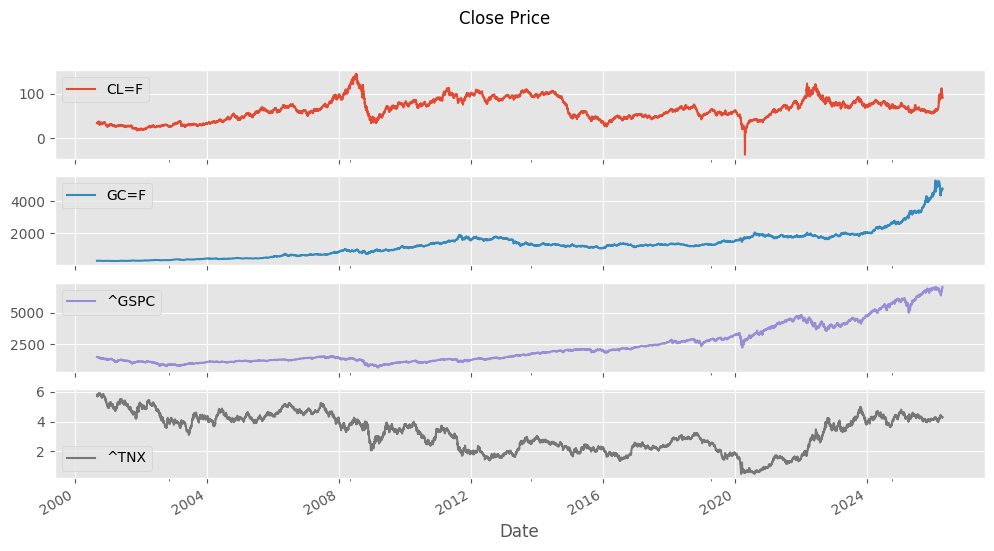

In [264]:
close.plot(title="Close Price", subplots=True, figsize=(12, 6))

/Users/bayesed/.pyenv/versions/3.13.7/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

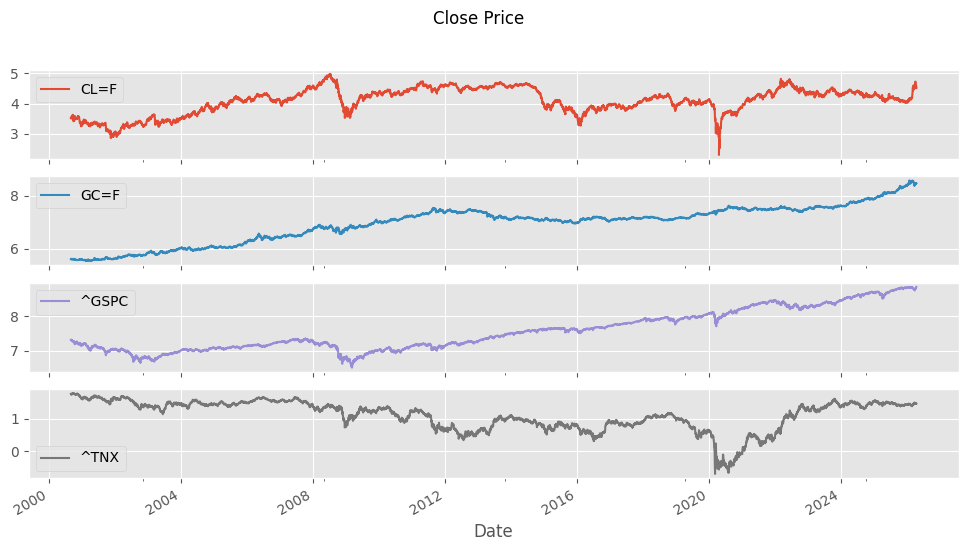

In [265]:
np.log(close).plot(title="Close Price", subplots=True, figsize=(12, 6))

In [266]:
logret = np.log(close).diff() # log(P_t) - log(P_{t-1})) = log(P_t / P_{t-1})
logret["^TNX"] = close["^TNX"].diff() # r_t(yiel) = P_t(yield) - P_{t-1}(yield)

# Aufräumen: erste Zeile NaN durch diff, ggf. weitere NaNs durch Datenlücken
logret = logret.dropna()

logret.head(), logret.tail()

/Users/bayesed/.pyenv/versions/3.13.7/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


(Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2000-08-31 -0.009023  0.015937  0.009993 -0.071
 2000-09-01  0.008424 -0.004682  0.002034 -0.054
 2000-09-05  0.012504 -0.004342 -0.009043  0.008
 2000-09-06  0.033458 -0.005818 -0.009889  0.029
 2000-09-07  0.010814 -0.000730  0.006852  0.037,
 Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2026-04-09  0.035993  0.008950  0.006151  0.002
 2026-04-10 -0.013372 -0.006343 -0.001139  0.024
 2026-04-13  0.025659 -0.004103  0.010122 -0.020
 2026-04-14 -0.081996  0.017267  0.011714 -0.041
 2026-04-15  0.000110 -0.005195  0.007944  0.026)

In [267]:
len(logret)

6415

## Data Export

In [268]:
import os
from pathlib import Path

In [269]:
project_dir = Path("/Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk")
data_dir = project_dir / "data"
output_dir = project_dir / "r/output"

data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

In [270]:
for pattern in (
    "logret_*.csv",
    "train_df_*.csv",
    "val_df_*.csv",
    "test_df_*.csv"
):
    for old_file in data_dir.glob(pattern):
        old_file.unlink()

In [271]:
logret

Ticker,CL=F,GC=F,^GSPC,^TNX
Date,,,,
2000-08-31,-0.009023,0.015937,0.009993,-0.071
2000-09-01,0.008424,-0.004682,0.002034,-0.054
2000-09-05,0.012504,-0.004342,-0.009043,0.008
2000-09-06,0.033458,-0.005818,-0.009889,0.029
2000-09-07,0.010814,-0.000730,0.006852,0.037
...,...,...,...,...
2026-04-09,0.035993,0.008950,0.006151,0.002
2026-04-10,-0.013372,-0.006343,-0.001139,0.024
2026-04-13,0.025659,-0.004103,0.010122,-0.020


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

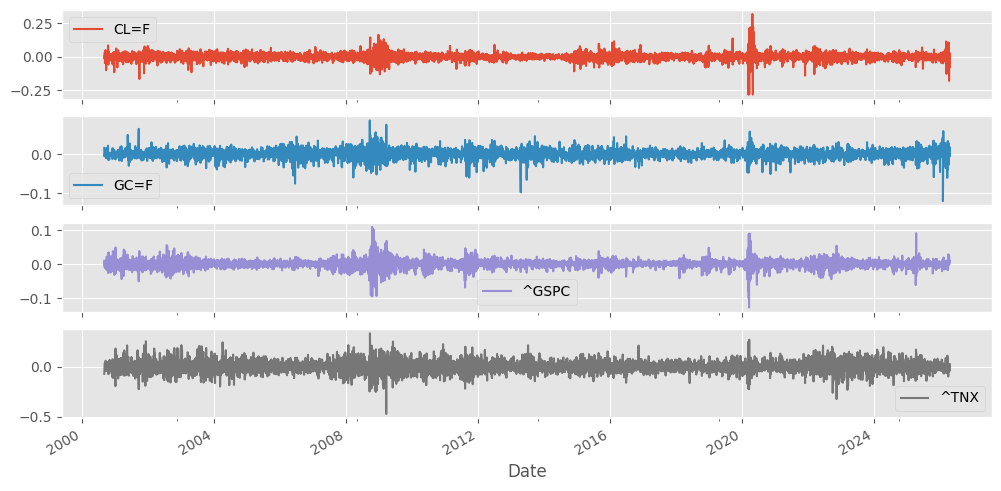

In [272]:
logret.plot(subplots=True, figsize=(12, 6))

array([[<Axes: title={'center': 'CL=F'}>,
        <Axes: title={'center': 'GC=F'}>],
       [<Axes: title={'center': '^GSPC'}>,
        <Axes: title={'center': '^TNX'}>]], dtype=object)

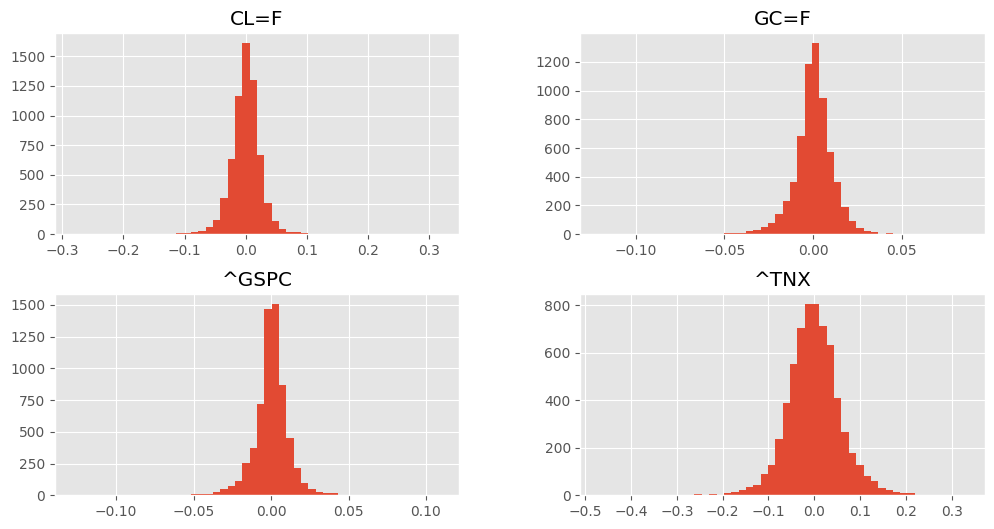

In [273]:
logret.hist(bins=50, figsize=(12, 6))

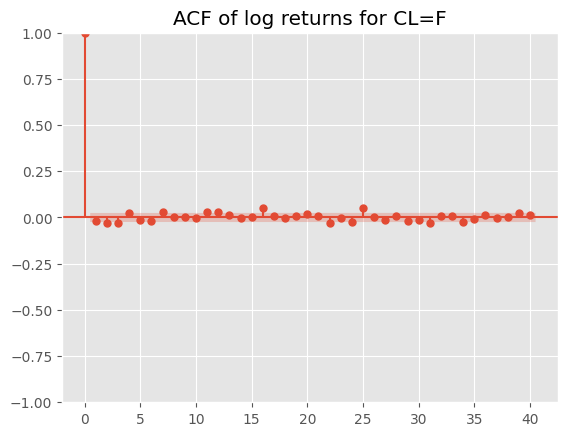

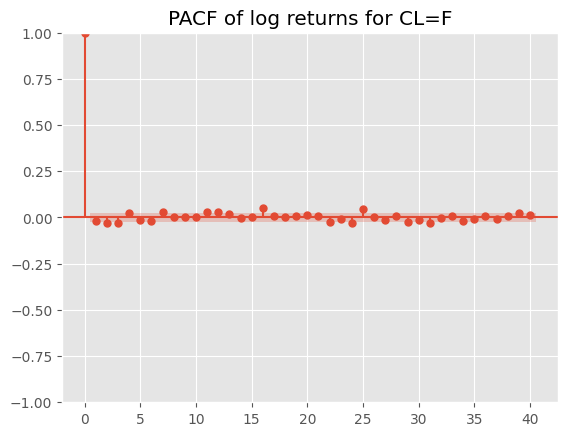

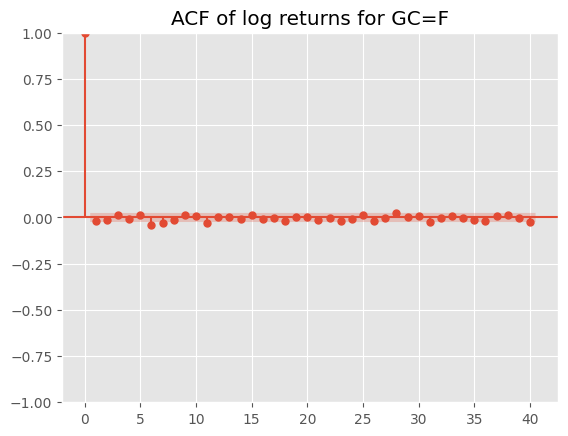

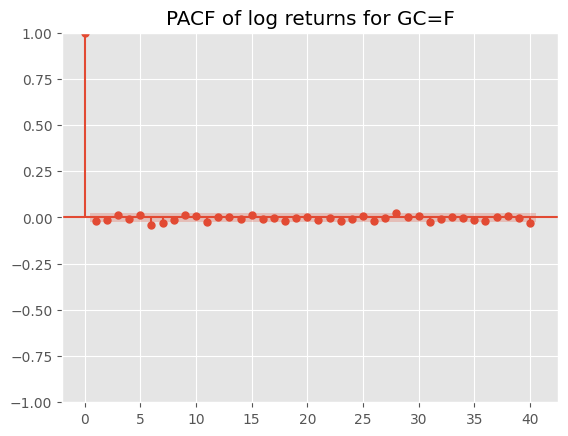

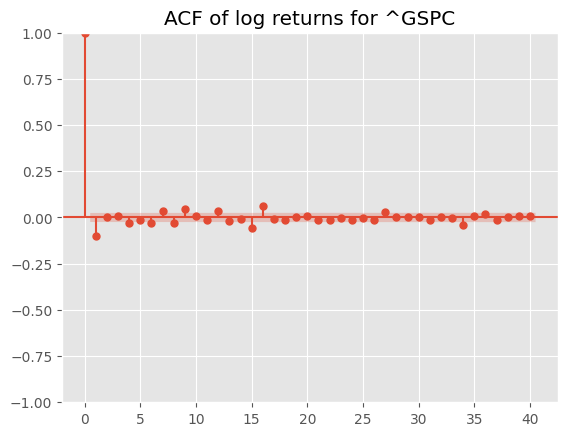

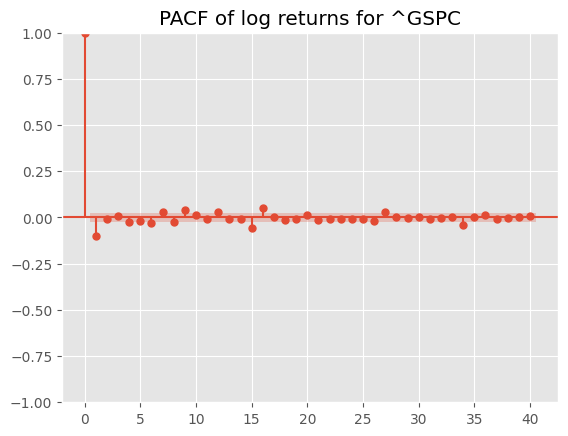

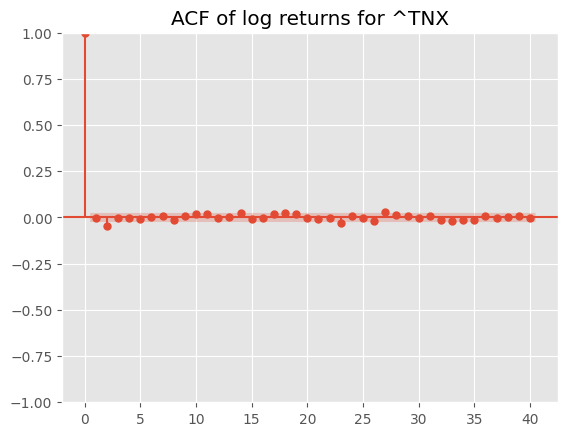

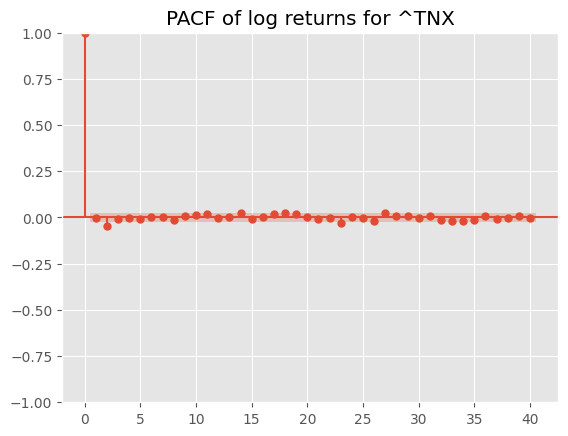

In [274]:
for col in logret.columns:
    plot_acf(logret[col], lags=40, title=f"ACF of log returns for {col}")
    plot_pacf(logret[col], lags=40, title=f"PACF of log returns for {col}")

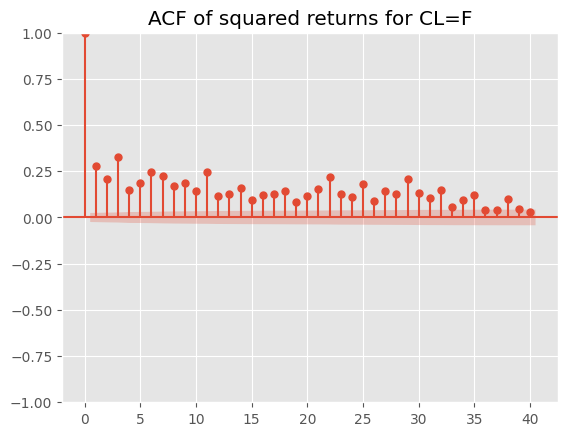

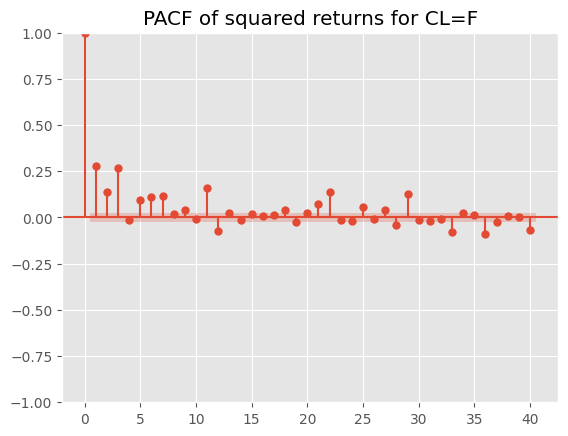

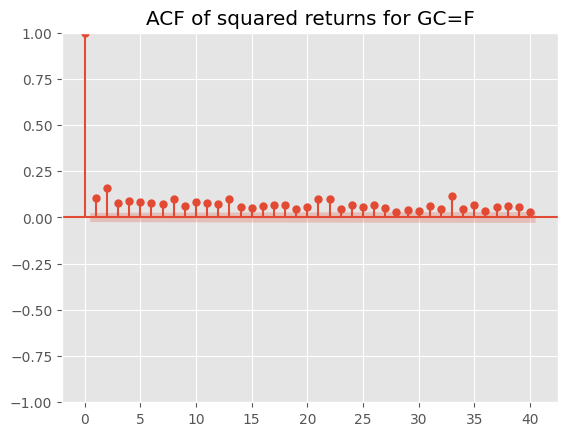

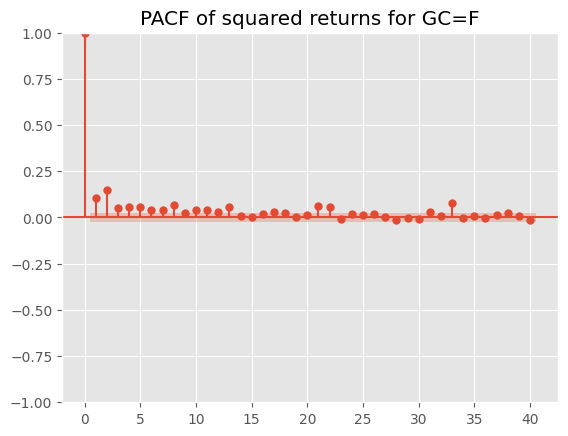

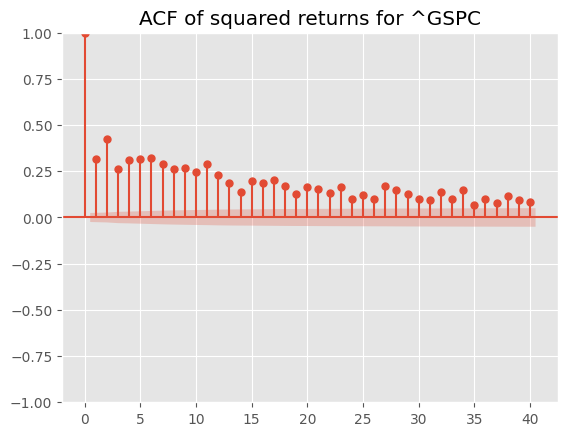

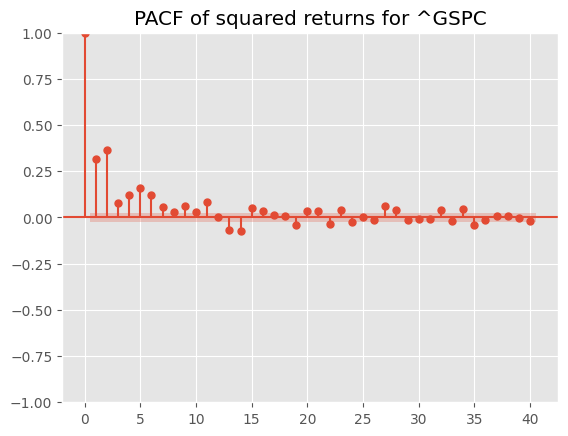

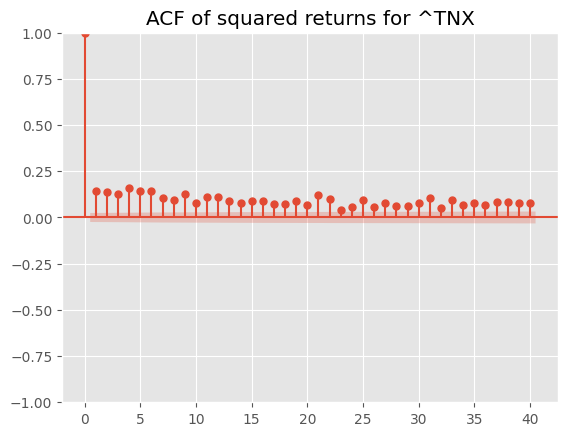

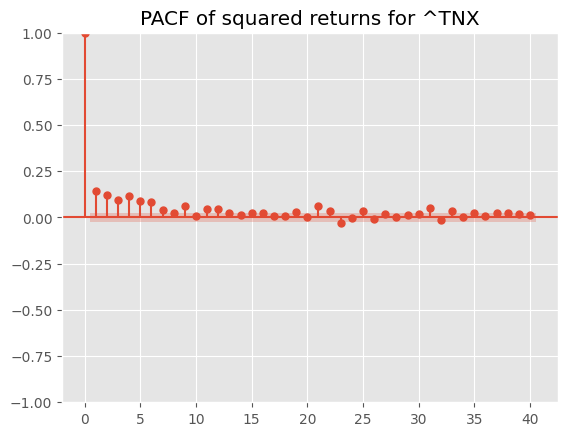

In [275]:
# squared returns
for col in logret.columns:
    plot_acf(logret[col]**2, lags=40, title=f"ACF of squared returns for {col}")
    plot_pacf(logret[col]**2, lags=40, title=f"PACF of squared returns for {col}")

In [276]:
from statsmodels.tsa.stattools import adfuller

for col in logret.columns:
    print(f"ADF test for {col}:")
    result = adfuller(logret[col])
    print(f"ADF statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("---")
    

ADF test for CL=F:
ADF statistic: -14.107883804904649
p-value: 2.5503706328081674e-26
---
ADF test for GC=F:
ADF statistic: -32.066235984094824
p-value: 0.0
---
ADF test for ^GSPC:
ADF statistic: -19.898903084318565
p-value: 0.0
---
ADF test for ^TNX:
ADF statistic: -59.50358620784016
p-value: 0.0
---


In [277]:
#feature_cols = macro_tickers.split(" ")

In [278]:
macro_tickers

['^GSPC', 'GC=F', 'CL=F', '^TNX']

In [279]:
R = logret[macro_tickers].values.astype(np.float32)   # (N,d)

# Outer products pro t: (N,d,1) * (N,1,d) -> (N,d,d)
U = R[:, :, None] * R[:, None, :]

In [280]:
cross_returns = vech(torch.tensor(U))
cross_returns.shape

torch.Size([6415, 10])

In [281]:
logret.shape

(6415, 4)

In [282]:
input_data = np.concatenate([logret[macro_tickers].values, cross_returns], axis=1)
input_df = pd.DataFrame(input_data, columns=macro_tickers + [f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [283]:
logret.index

DatetimeIndex(['2000-08-31', '2000-09-01', '2000-09-05', '2000-09-06',
               '2000-09-07', '2000-09-08', '2000-09-11', '2000-09-12',
               '2000-09-13', '2000-09-14',
               ...
               '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07',
               '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13',
               '2026-04-14', '2026-04-15'],
              dtype='datetime64[ns]', name='Date', length=6415, freq=None)

In [284]:
input_df.index = logret.index

In [285]:
input_df

,^GSPC,GC=F,CL=F,^TNX,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
Date,,,,,,,,,,,,,,
2000-08-31,0.009993,0.015937,-0.009023,-0.071,0.000100,0.000159,-9.016055e-05,-0.000709,2.539743e-04,-1.437910e-04,-0.001131,8.140928e-05,0.000641,0.005041
2000-09-01,0.002034,-0.004682,0.008424,-0.054,0.000004,-0.000010,1.713308e-05,-0.000110,2.192223e-05,-3.944083e-05,0.000253,7.095896e-05,-0.000455,0.002916
2000-09-05,-0.009043,-0.004342,0.012504,0.008,0.000082,0.000039,-1.130699e-04,-0.000072,1.884936e-05,-5.428644e-05,-0.000035,1.563458e-04,0.000100,0.000064
2000-09-06,-0.009889,-0.005818,0.033458,0.029,0.000098,0.000058,-3.308608e-04,-0.000287,3.385040e-05,-1.946606e-04,-0.000169,1.119418e-03,0.000970,0.000841
2000-09-07,0.006852,-0.000730,0.010814,0.037,0.000047,-0.000005,7.409770e-05,0.000254,5.324698e-07,-7.891049e-06,-0.000027,1.169431e-04,0.000400,0.001369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,0.006151,0.008950,0.035993,0.002,0.000038,0.000055,2.213957e-04,0.000012,8.010765e-05,3.221482e-04,0.000018,1.295500e-03,0.000072,0.000004
2026-04-10,-0.001139,-0.006343,-0.013372,0.024,0.000001,0.000007,1.523294e-05,-0.000027,4.023250e-05,8.481716e-05,-0.000152,1.788095e-04,-0.000321,0.000576
2026-04-13,0.010122,-0.004103,0.025659,-0.020,0.000102,-0.000042,2.597222e-04,-0.000202,1.683798e-05,-1.052915e-04,0.000082,6.584096e-04,-0.000513,0.000400


In [286]:
cross_df = pd.DataFrame(cross_returns, columns=[f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [287]:
cross_df

,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
0,0.000100,0.000159,-9.016055e-05,-0.000709,2.539743e-04,-1.437910e-04,-0.001131,8.140928e-05,0.000641,0.005041
1,0.000004,-0.000010,1.713308e-05,-0.000110,2.192223e-05,-3.944083e-05,0.000253,7.095896e-05,-0.000455,0.002916
2,0.000082,0.000039,-1.130699e-04,-0.000072,1.884936e-05,-5.428644e-05,-0.000035,1.563458e-04,0.000100,0.000064
3,0.000098,0.000058,-3.308608e-04,-0.000287,3.385040e-05,-1.946606e-04,-0.000169,1.119418e-03,0.000970,0.000841
4,0.000047,-0.000005,7.409770e-05,0.000254,5.324698e-07,-7.891049e-06,-0.000027,1.169431e-04,0.000400,0.001369
...,...,...,...,...,...,...,...,...,...,...
6410,0.000038,0.000055,2.213957e-04,0.000012,8.010765e-05,3.221482e-04,0.000018,1.295500e-03,0.000072,0.000004
6411,0.000001,0.000007,1.523294e-05,-0.000027,4.023250e-05,8.481716e-05,-0.000152,1.788095e-04,-0.000321,0.000576
6412,0.000102,-0.000042,2.597222e-04,-0.000202,1.683798e-05,-1.052915e-04,0.000082,6.584096e-04,-0.000513,0.000400
6413,0.000137,0.000202,-9.604995e-04,-0.000480,2.981638e-04,-1.415858e-03,-0.000708,6.723333e-03,0.003362,0.001681


In [288]:
def train_val_test_split(df, train_size=0.7, val_size=0.15):
    n = len(df)
    test_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    train_df = df.iloc[:test_end]
    val_df = df.iloc[test_end:val_end]
    test_df = df.iloc[val_end:]
    
    return train_df, val_df, test_df

In [289]:
train_df, val_df, test_df = train_val_test_split(input_df)

In [290]:
train_df.index.name

'Date'

In [291]:
import datetime

In [292]:
run_id = datetime.datetime.now().strftime("%Y-%m-%d")

exports = {
    "logret": logret[macro_tickers],
    "train_df": train_df[macro_tickers],
    "val_df": val_df[macro_tickers],
    "test_df": test_df[macro_tickers],
}

for name, df_export in exports.items():
    df_export = df_export.copy()
    df_export.index.name = "Date"
    df_export.to_csv(data_dir / f"{name}_{run_id}.csv")

print(f"Exportiert mit run_id: {run_id}")


Exportiert mit run_id: 2026-04-16


## Vola

Wir modellieren nun
$\mathbf r_{t+1}\mid\mathcal F_t \sim \mathcal N(\mathbf 0, \Sigma_{t+1}),$
und lassen das LSTM direkt eine gueltige Kovarianzmatrix $\Sigma_{t+1}$ ausgeben.

Dazu parametrisieren wir $\Sigma_{t+1} = L_{t+1}L_{t+1}^\top$ mit einer unteren Dreiecksmatrix $L_{t+1}$ (Cholesky-Form).
Die Diagonale von $L_{t+1}$ wird mit `softplus` strikt positiv gemacht.


In [293]:
#feature_cols = tickers.split(" ")
mu = train_df.mean()
sigma = train_df.std() # vielleicht nicht durch die Std teilen

def normalize(df, mu, sigma, with_std=True):
    if with_std:
        return (df - mu) / sigma
    else:
        return df - mu

In [294]:
lookback = 60
batchsize = 128

In [295]:
train_norm = normalize(train_df, mu, sigma, with_std=True)
val_norm = normalize(val_df, mu, sigma, with_std=True)
test_norm = normalize(test_df, mu, sigma, with_std=True)

vol_train_ds = SequenceDataset(
    train_norm.values,
    train_norm[macro_tickers].values,
    lookback,
)
vol_val_ds = SequenceDataset(
    val_norm.values,
    val_norm[macro_tickers].values,
    lookback,
)
vol_test_ds = SequenceDataset(
    test_norm.values,
    test_norm[macro_tickers].values,
    lookback,
)

vol_train_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=True)
vol_val_loader = DataLoader(vol_val_ds, batch_size=batchsize, shuffle=False)
vol_test_loader = DataLoader(vol_test_ds, batch_size=batchsize, shuffle=False)


In [296]:
len(vol_train_ds), len(vol_val_ds), len(vol_test_ds)

(4430, 902, 903)

```train_cov```ggf. zur Initialisierung nutzen. 

In [ ]:
train_cov = torch.cov(torch.tensor(train_norm[macro_tickers].values, dtype=torch.float32,).T)  # sample / long-term covariance from training data
train_cov

tensor([[ 1.0000, -0.0334,  0.2120,  0.3630],
        [-0.0334,  1.0000,  0.2228, -0.1268],
        [ 0.2120,  0.2228,  1.0000,  0.1833],
        [ 0.3630, -0.1268,  0.1833,  1.0000]])

In [300]:
from LSTMCovariance import LSTMCovariance
from training_functions import train_covariance_model, gaussian_nll, student_nll

In [301]:
k = len(macro_tickers)*(len(macro_tickers)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model = LSTMCovariance(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, num_layers=2, dropout=0.2)
cov_model, hist = train_covariance_model(
    cov_model,
    vol_train_loader,
    vol_val_loader,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 6.380275 | val NLL 8.177317 | lr 1.00e-04
Epoch 002 | train NLL 6.062208 | val NLL 7.668037 | lr 1.00e-04
Epoch 003 | train NLL 5.766627 | val NLL 7.182965 | lr 1.00e-04
Epoch 004 | train NLL 5.523244 | val NLL 6.728541 | lr 1.00e-04
Epoch 005 | train NLL 5.367809 | val NLL 6.373250 | lr 1.00e-04
Epoch 006 | train NLL 5.243759 | val NLL 6.118379 | lr 1.00e-04
Epoch 007 | train NLL 5.181487 | val NLL 5.994848 | lr 1.00e-04
Epoch 008 | train NLL 5.148542 | val NLL 5.913891 | lr 9.99e-05
Epoch 009 | train NLL 5.127251 | val NLL 5.858770 | lr 9.99e-05
Epoch 010 | train NLL 5.104952 | val NLL 5.833819 | lr 9.99e-05
Epoch 011 | train NLL 5.094694 | val NLL 5.833296 | lr 9.99e-05
Epoch 012 | train NLL 5.081992 | val NLL 5.786832 | lr 9.99e-05
Epoch 013 | train NLL 5.068954 | val NLL 5.762304 | lr 9.98e-05
Epoch 014 | train NLL 5.059980 | val NLL 5.740222 | lr 9.98e-05
Epoch 015 | train NLL 5.043905 | val NLL 5.727086 | lr 9.98e-05
Epoch 016 | train NLL 5.038943 | val NLL

In [302]:
from plots import plot_loss

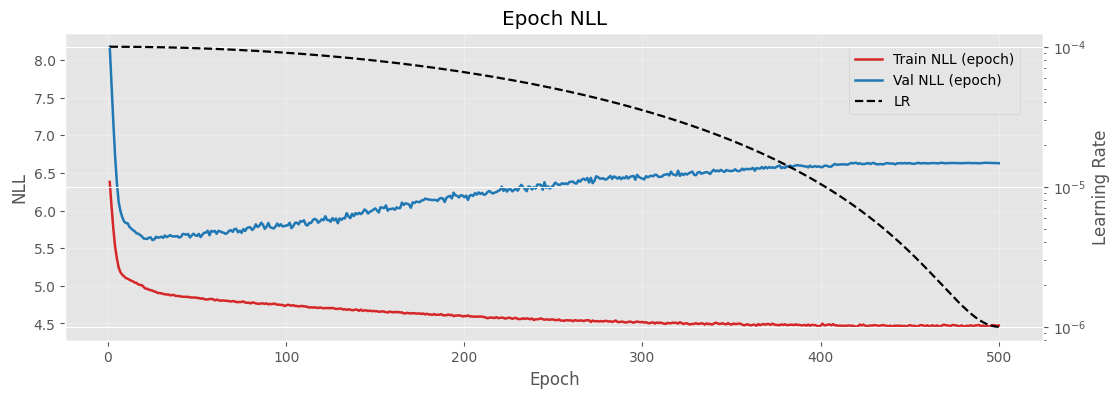

In [303]:
plot_loss(hist)

In [304]:
sigma

^GSPC       0.012005
GC=F        0.011287
CL=F        0.023759
^TNX        0.057884
cross_1     0.000478
cross_2     0.000225
cross_3     0.000493
cross_4     0.001174
cross_5     0.000347
cross_6     0.000380
cross_7     0.000887
cross_8     0.001401
cross_9     0.001848
cross_10    0.007074
dtype: float64

In [305]:
def predict_sigma(model, loader, device='cpu'):
    model.eval()
    sigmas = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            sigma_pred, _ = model(xb)
            sigmas.append(sigma_pred.cpu().numpy())
            targets.append(yb.numpy())

    return np.concatenate(sigmas, axis=0), np.concatenate(targets, axis=0)


sigma_val_scaled, y_val_scaled = predict_sigma(cov_model, vol_val_loader, device=device)
sigma_test_scaled, y_test_scaled = predict_sigma(cov_model, vol_test_loader, device=device)

# Transform covariance back to original return scale:
# if z = (r - mu)/std, then Cov(r) = D Cov(z) D with D = diag(std)

def scale_back(sigma_scaled, sigma=None, feature_cols=None):
    if sigma is not None and feature_cols is not None:
        std_vec = sigma[feature_cols].values.astype(np.float32)
        return sigma_scaled * std_vec[None, :, None] * std_vec[None, None, :]
    else:
        return sigma_scaled

sigma_val_real = scale_back(sigma_val_scaled, sigma=sigma, feature_cols=macro_tickers)
sigma_test_real = scale_back(sigma_test_scaled, sigma=sigma, feature_cols=macro_tickers)

print('sigma_val_scaled:', sigma_val_scaled.shape)
print('sigma_test_scaled:', sigma_test_scaled.shape)
print('sigma_test_real:', sigma_test_real.shape)
print('sigma_val_real:', sigma_val_real.shape)


sigma_val_scaled: (902, 4, 4)
sigma_test_scaled: (903, 4, 4)
sigma_test_real: (903, 4, 4)
sigma_val_real: (902, 4, 4)


In [306]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False) # ohne Shuffle, für Plots

In [307]:
sigma_train_scaled, y_train_scaled = predict_sigma(cov_model, vol_train_eval_loader, device=device)
sigma_train_real = scale_back(sigma_train_scaled, sigma=sigma, feature_cols=macro_tickers)

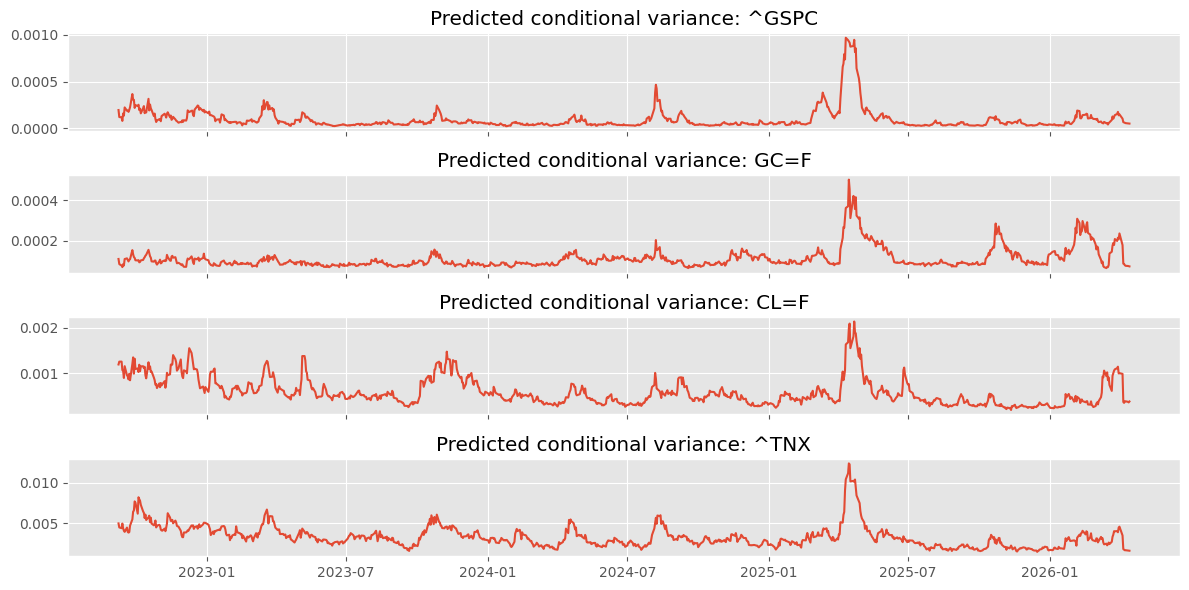

In [308]:
# Quick diagnostic plot: predicted conditional variances
# Build a time index + diagonal variance frame first
test_index_vol = test_df.index[lookback:]
sigma_test_diag_df = pd.DataFrame(
    {
        f'Var({macro_tickers[i]})': sigma_test_real[:, i, i]
        for i in range(len(macro_tickers))
    },
    index=test_index_vol,
)

fig, axes = plt.subplots(len(macro_tickers), 1, figsize=(12, 6), sharex=True)
if len(macro_tickers) == 1:
    axes = [axes]

for i, col in enumerate(macro_tickers):
    axes[i].plot(sigma_test_diag_df.index, sigma_test_diag_df[f'Var({col})'])
    axes[i].set_title(f'Predicted conditional variance: {col}')

plt.tight_layout()
plt.show()


In [309]:
from statistics import NormalDist
from scipy.stats import t

In [310]:
def plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split", df=test_df, pred_vol=sigma_test_real, portfolio=False, portfolio_df=None, loss_fn=gaussian_nll, loss_kwargs=None):

    if loss_fn == gaussian_nll:
        z_lo = NormalDist().inv_cdf(alpha)        # z_{alpha}, z.B. -2.326
        z_hi = NormalDist().inv_cdf(1.0 - alpha)  # z_{1-alpha}, z.B. +2.326
    elif loss_fn == student_nll:
        nu = loss_kwargs.get("nu")
        z_lo = t.ppf(alpha, df=nu)
        z_hi = t.ppf(1-alpha, df=nu)

        # muss die Varianz hier noch mit einem Faktor (nu/(nu-2)) skaliert werden, 
        # damit sie mit der Gaussian Varianz vergleichbar ist?

    index_vol = df.index[lookback:]
    rets = df.loc[index_vol, cols].copy()
    
    if portfolio:
        if portfolio_df is None:
            raise ValueError("Bei portfolio=True bitte portfolio_df übergeben.")
        
        idx = portfolio_df.index
        r = portfolio_df["r_p"].values
        vol = portfolio_df["vol_p"].values

        var_lo = z_lo * vol
        var_hi = z_hi * vol

        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Portfolio Return", alpha=0.8) 
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} Quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"Portfolio: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        hit_rate = np.mean(r < var_lo)
        print(f"Portfolio hit rate = {hit_rate:.3%} (target {alpha:.3%})")
        return

    for i, col in enumerate(cols):
        # sigma_{t+1} aus deiner vorhergesagten Kovarianz Matrix für die Asset i extrahieren
        sigma_t = np.sqrt(np.clip(pred_vol[:, i, i], 1e-12, None))

        var_lo = z_lo * sigma_t   # downside VaR-Linie
        var_hi = z_hi * sigma_t   # obere symmetrische Linie

        r = rets[col].values
        idx = rets.index

        plt.style.use("ggplot")
        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Return", alpha=0.7)
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"{col}: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Backtest: Anteil der Unterschreitungen sollte ~ alpha sein
        hit_rate = np.mean(r < var_lo)
        print(f"{col}: hit rate = {hit_rate:.3%} (target {alpha:.3%})")


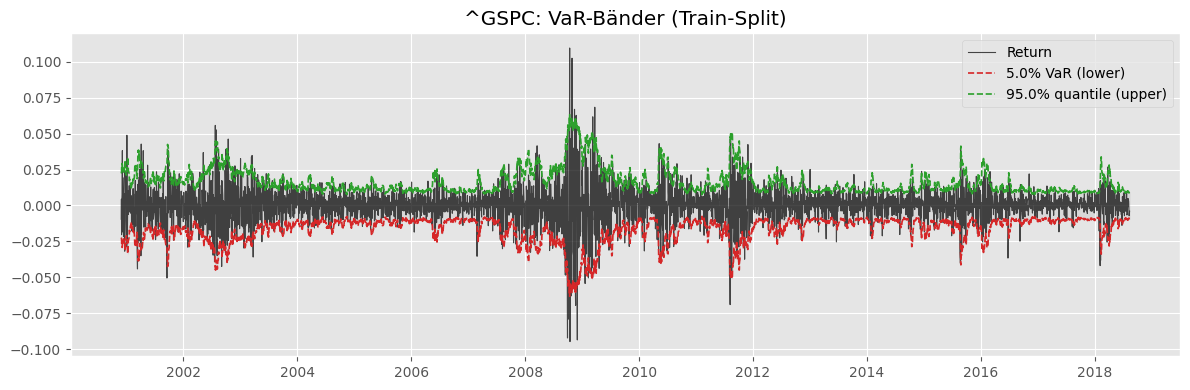

^GSPC: hit rate = 5.756% (target 5.000%)


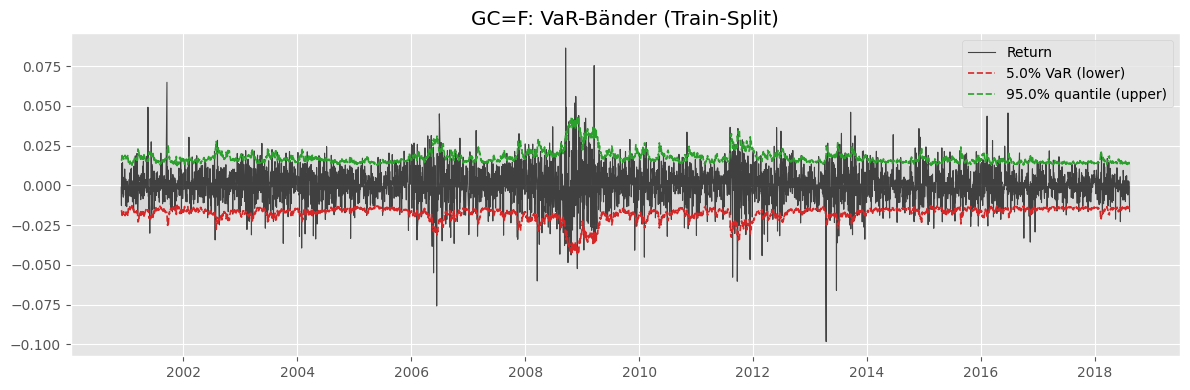

GC=F: hit rate = 4.898% (target 5.000%)


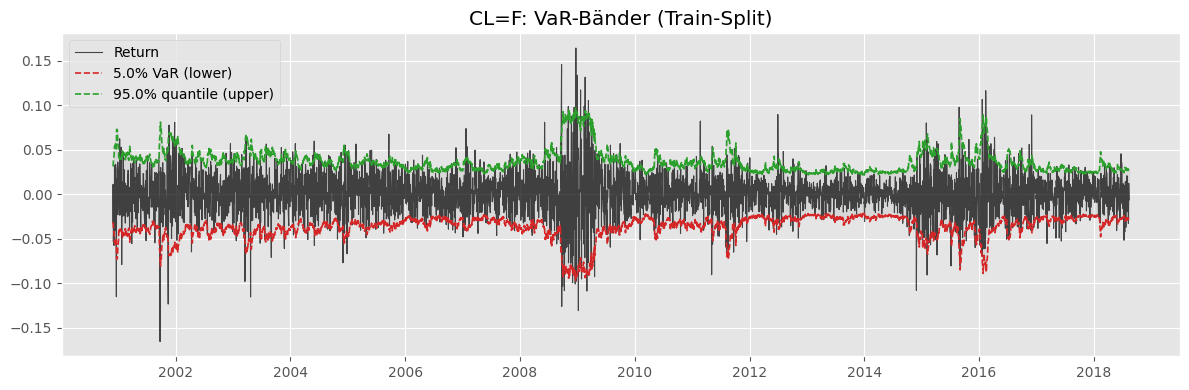

CL=F: hit rate = 4.695% (target 5.000%)


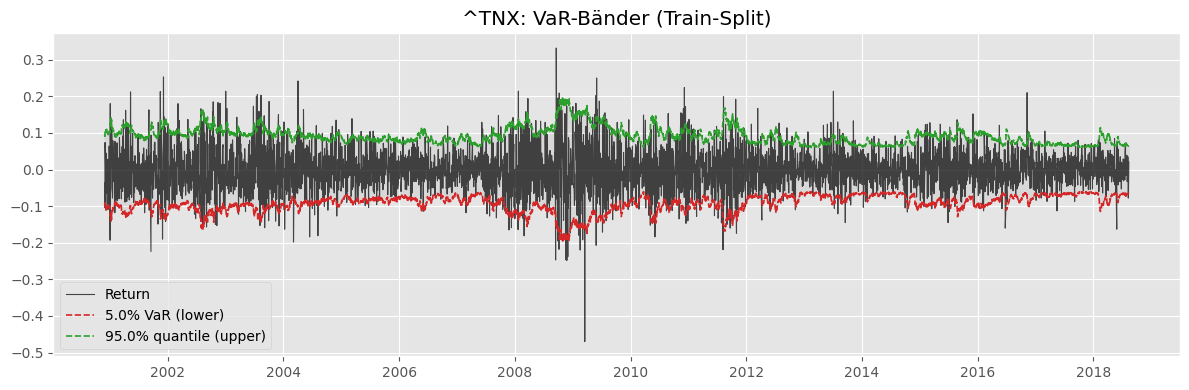

^TNX: hit rate = 4.153% (target 5.000%)


In [311]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Train-Split", df=train_df, pred_vol=sigma_train_real)

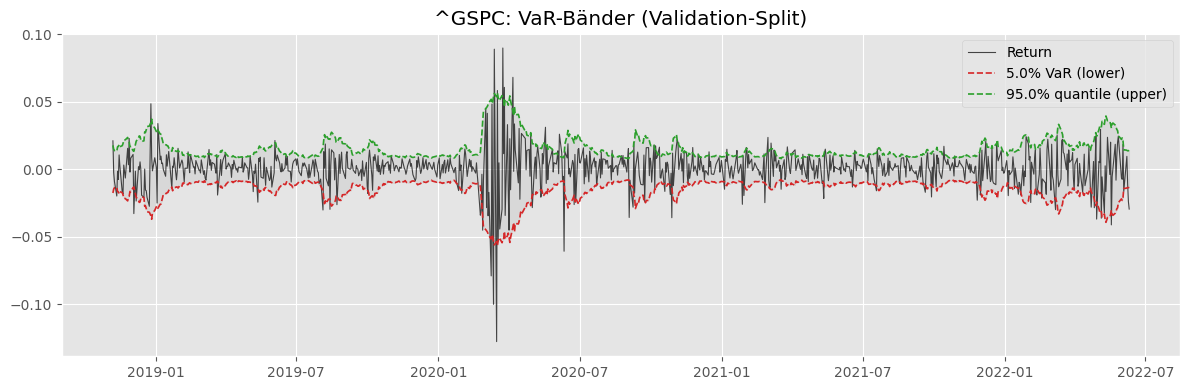

^GSPC: hit rate = 7.982% (target 5.000%)


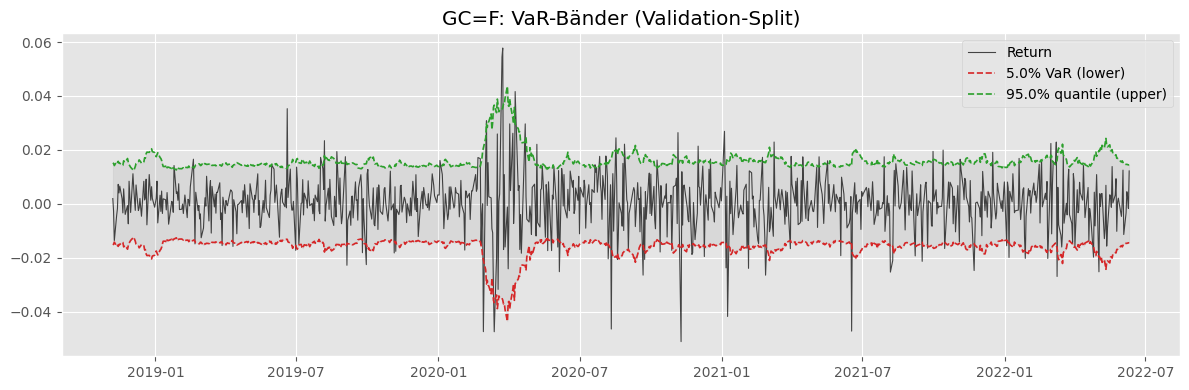

GC=F: hit rate = 5.765% (target 5.000%)


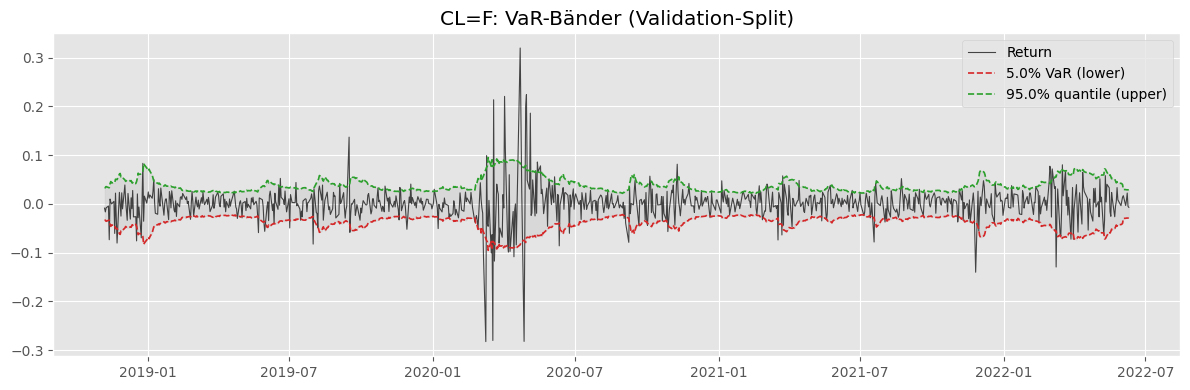

CL=F: hit rate = 6.984% (target 5.000%)


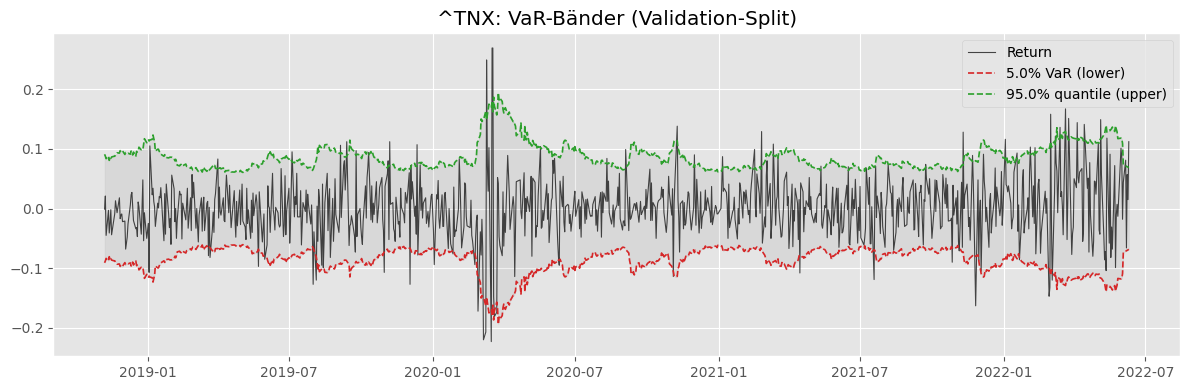

^TNX: hit rate = 3.215% (target 5.000%)


In [312]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Validation-Split", df=val_df, pred_vol=sigma_val_real)

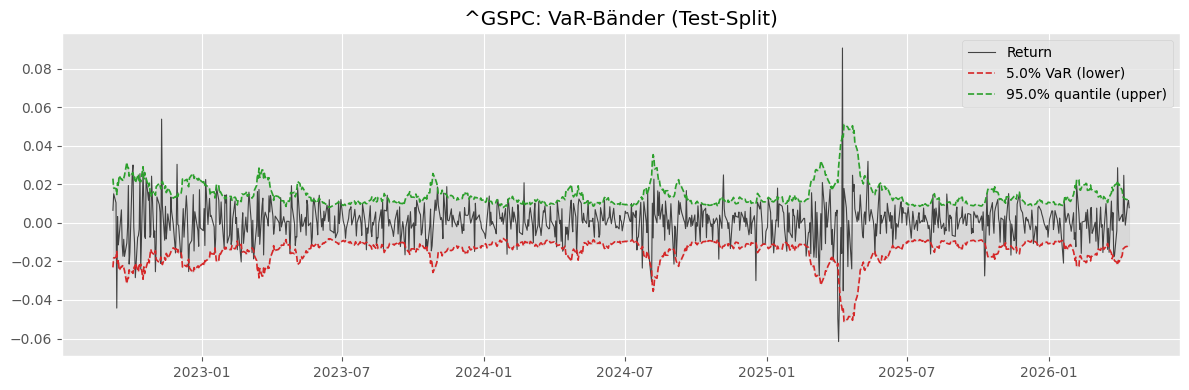

^GSPC: hit rate = 6.423% (target 5.000%)


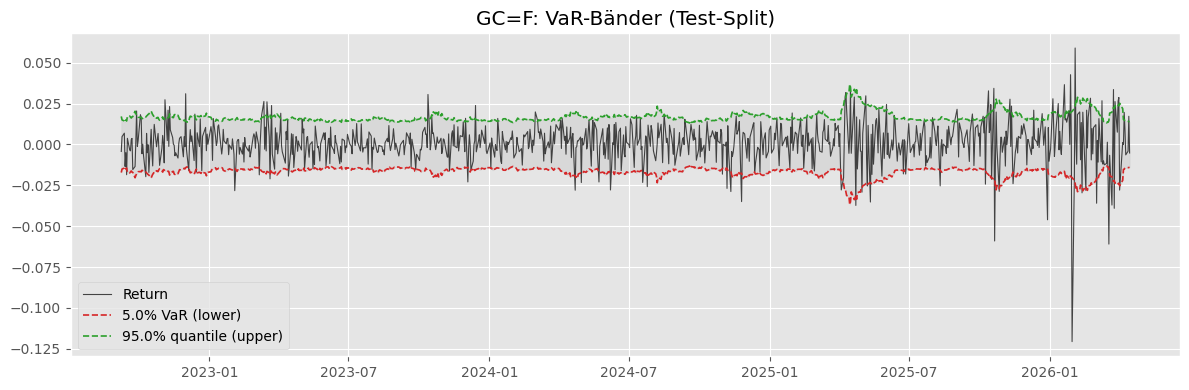

GC=F: hit rate = 5.316% (target 5.000%)


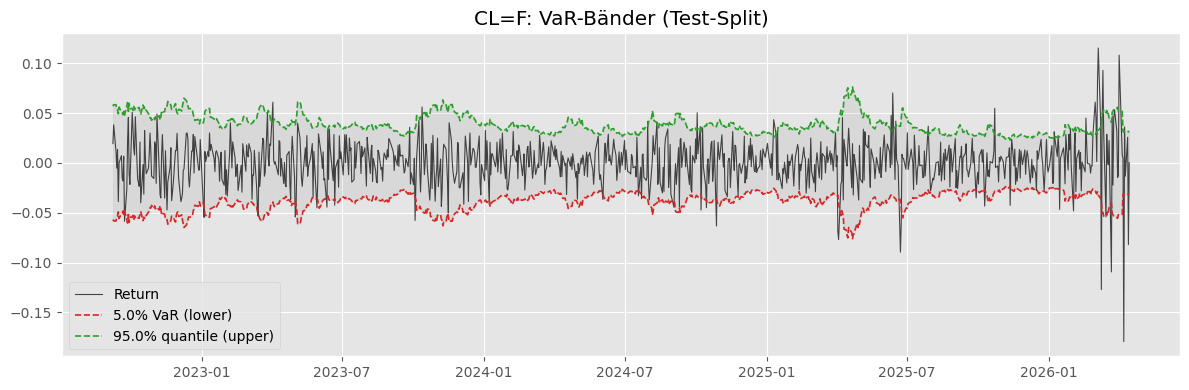

CL=F: hit rate = 3.433% (target 5.000%)


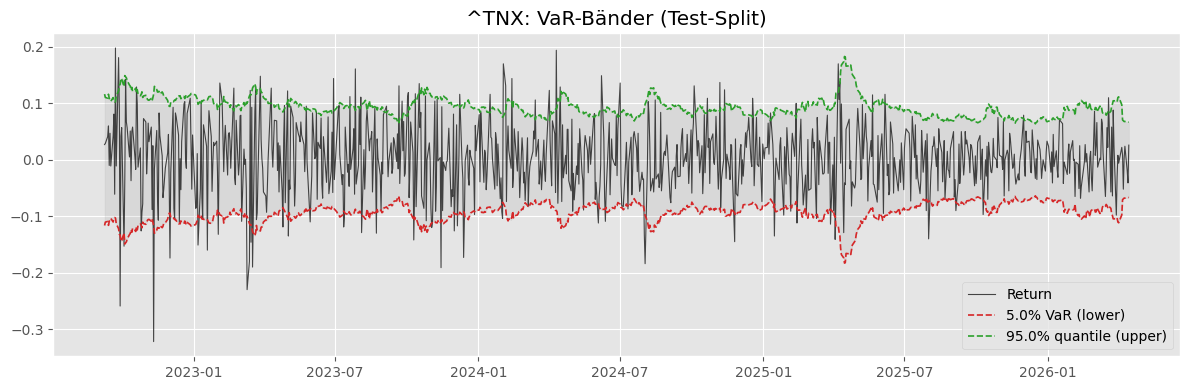

^TNX: hit rate = 5.759% (target 5.000%)


In [313]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Test-Split", df=test_df, pred_vol=sigma_test_real)

In [314]:
train_df.shape, val_df.shape, test_df.shape

((4490, 14), (962, 14), (963, 14))

# Portfolio Berechnungen

Portfolio Weights & Portfolio Return $r_{p,t} = w^\top \cdot r_t$

$w = (w_1, w_2, \dots, w_n)^\top$ mit $\sum_i^n w_i = 1$

Portfolio Variance:

$\sigma^2_{p,t} = w^\top \Sigma_t w$


In [315]:
w = torch.tensor([0.25, 0.25, 0.25, 0.25], dtype=torch.float32).to(device)  # gleichgewichtetes Portfolio

In [316]:
#w = torch.tensor([0.5, 0.4, 0.1])

In [317]:
w.shape

torch.Size([4])

In [318]:
logret.shape

(6415, 4)

In [319]:
torch.tensor(logret.values).shape

torch.Size([6415, 4])

In [320]:
logret_tensor = torch.tensor(logret.values, dtype=torch.float32, device=w.device)

In [321]:
w.shape

torch.Size([4])

In [322]:
logret_tensor.shape

torch.Size([6415, 4])

In [323]:
portfolio_logrets = (w * logret_tensor).sum(dim=1)

In [324]:
portfolio_logrets.shape

torch.Size([6415])

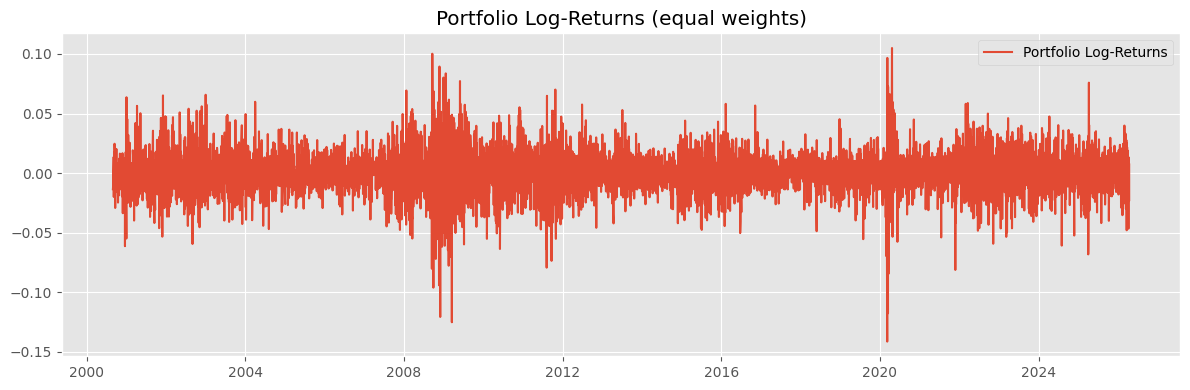

In [325]:
portfolio_logrets_np = portfolio_logrets.detach().cpu().numpy()
plt.figure(figsize=(12, 4))
plt.plot(logret.index, portfolio_logrets_np, label="Portfolio Log-Returns")
plt.title("Portfolio Log-Returns (equal weights)")
plt.legend()
plt.tight_layout()
plt.show()

In [326]:
#w = np.array([0.5, 0.4, 0.1], dtype=np.float32)
#w

In [327]:
def calc_portfolio_variance(df_split, sigma_split, cols, lookback, w):
    idx = df_split.index[lookback:]
    r = df_split.loc[idx, cols].values  # (N-lookback, d)
    r_p = (w*r).sum(axis=1)  # (N-lookback,) Portfolio-Logreturns
    tmp = sigma_split @ w          # (T, d)  = Σ_t w
    var_p = (w * tmp).sum(axis=1) # (1,) = w^T (Σ_t w) Portfolio-Varianz pro t
    vol_p = np.sqrt(var_p)
    
    return idx, r_p, var_p, vol_p

## LSTM mit Normal Loss

In [328]:
w_np = w.detach().cpu().numpy()

In [329]:
sigma_train_real.shape

(4430, 4, 4)

In [330]:
idx_test, rp_test, varp_test, volp_test = calc_portfolio_variance(
    test_df, sigma_test_real, macro_tickers, lookback, w_np
)

idx_val, rp_val, varp_val, volp_val = calc_portfolio_variance(
    val_df, sigma_val_real, macro_tickers, lookback, w_np
)

idx_train, rp_train, varp_train, volp_train = calc_portfolio_variance(
    train_df, sigma_train_real, macro_tickers, lookback, w_np
)

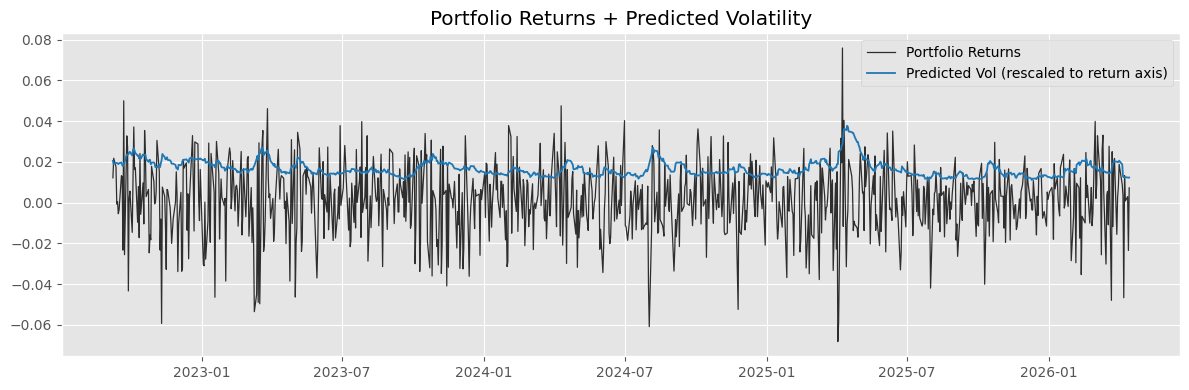

In [331]:
r = np.asarray(rp_test, dtype=float)
v = np.asarray(volp_test, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [332]:
def make_portfolio_df(idx, rp, varp, volp):
    return pd.DataFrame(
        {
            "r_p": np.asarray(rp, dtype=float),
            "var_p": np.asarray(varp, dtype=float),
            "vol_p": np.asarray(volp, dtype=float),
        },
        index=idx,
    )

In [333]:
portfolio_test = make_portfolio_df(idx_test, rp_test, varp_test, volp_test)
portfolio_val = make_portfolio_df(idx_val, rp_val, varp_val, volp_val)
portfolio_train = make_portfolio_df(idx_train, rp_train, varp_train, volp_train)

In [334]:
test_df.columns

Index(['^GSPC', 'GC=F', 'CL=F', '^TNX', 'cross_1', 'cross_2', 'cross_3',
       'cross_4', 'cross_5', 'cross_6', 'cross_7', 'cross_8', 'cross_9',
       'cross_10'],
      dtype='object')

In [335]:
macro_tickers

['^GSPC', 'GC=F', 'CL=F', '^TNX']

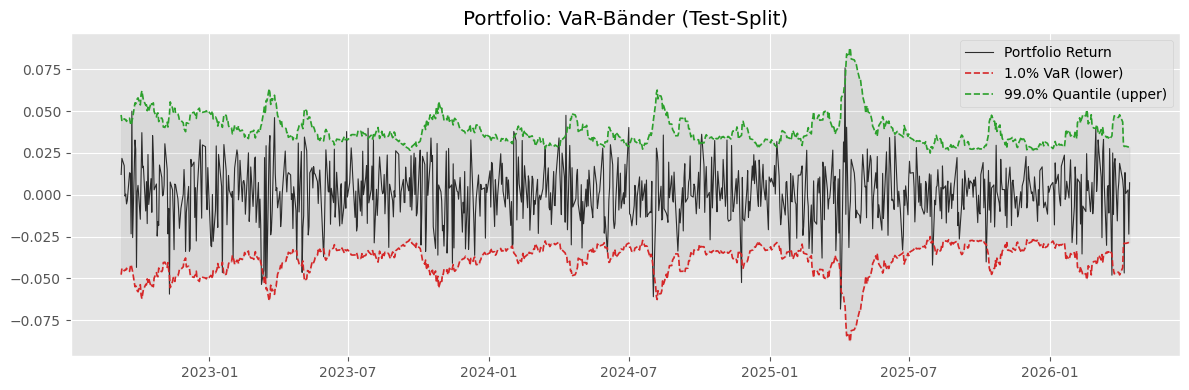

Portfolio hit rate = 2.215% (target 1.000%)


In [336]:
plot_var(alpha=0.01, lookback=lookback, view="Test-Split", portfolio=True, portfolio_df=portfolio_test)

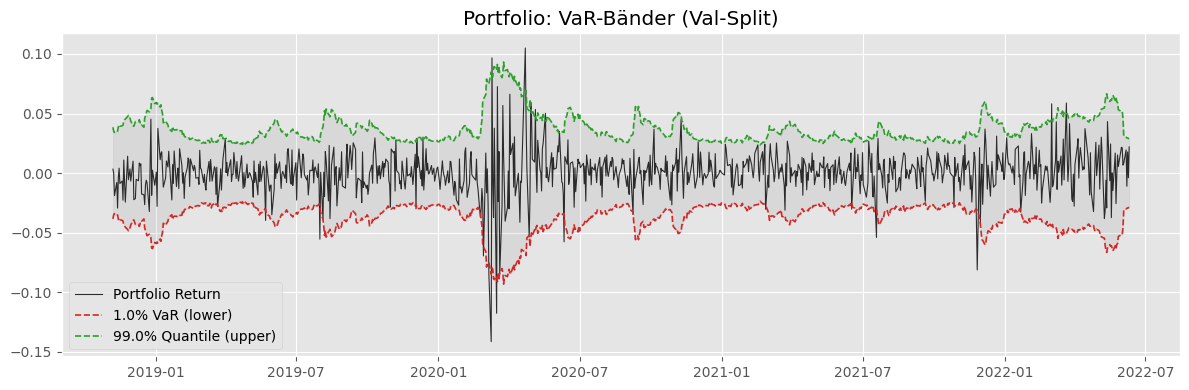

Portfolio hit rate = 1.996% (target 1.000%)


In [337]:
plot_var(alpha=0.01, lookback=lookback, view="Val-Split", portfolio=True, portfolio_df=portfolio_val)

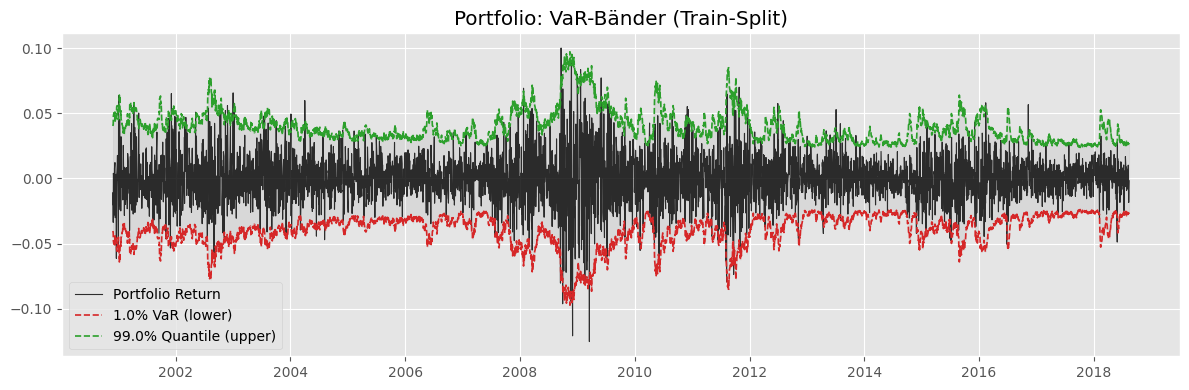

Portfolio hit rate = 1.309% (target 1.000%)


In [338]:
plot_var(alpha=0.01, lookback=lookback, view="Train-Split", portfolio=True, portfolio_df=portfolio_train)

## LSTM mit Student-t Loss

### Training

Modell mit Studen-t-Verteilung

In [339]:
loss_kwargs = {"nu": 5.0}  # vieleicht mit trainieren?

In [340]:
k = len(macro_tickers)*(len(macro_tickers)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model_t = LSTMCovariance(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, num_layers=2, dropout=0.2)
cov_model_t, hist_t = train_covariance_model(
    cov_model_t,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

/Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/training_functions.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nu = torch.tensor(nu, device=y.device, dtype=y.dtype)


Epoch 001 | train NLL 5.244316 | val NLL 5.416527 | lr 1.00e-04
Epoch 002 | train NLL 5.192099 | val NLL 5.410325 | lr 1.00e-04
Epoch 003 | train NLL 5.164570 | val NLL 5.405805 | lr 1.00e-04
Epoch 004 | train NLL 5.137854 | val NLL 5.397123 | lr 1.00e-04
Epoch 005 | train NLL 5.122170 | val NLL 5.381150 | lr 1.00e-04
Epoch 006 | train NLL 5.101059 | val NLL 5.354646 | lr 1.00e-04
Epoch 007 | train NLL 5.070025 | val NLL 5.325056 | lr 1.00e-04
Epoch 008 | train NLL 5.039572 | val NLL 5.289243 | lr 9.99e-05
Epoch 009 | train NLL 4.996595 | val NLL 5.269217 | lr 9.99e-05
Epoch 010 | train NLL 4.975406 | val NLL 5.256587 | lr 9.99e-05
Epoch 011 | train NLL 4.956935 | val NLL 5.240166 | lr 9.99e-05
Epoch 012 | train NLL 4.937706 | val NLL 5.232194 | lr 9.99e-05
Epoch 013 | train NLL 4.924432 | val NLL 5.223683 | lr 9.98e-05
Epoch 014 | train NLL 4.910919 | val NLL 5.206052 | lr 9.98e-05
Epoch 015 | train NLL 4.897721 | val NLL 5.205289 | lr 9.98e-05
Epoch 016 | train NLL 4.887159 | val NLL

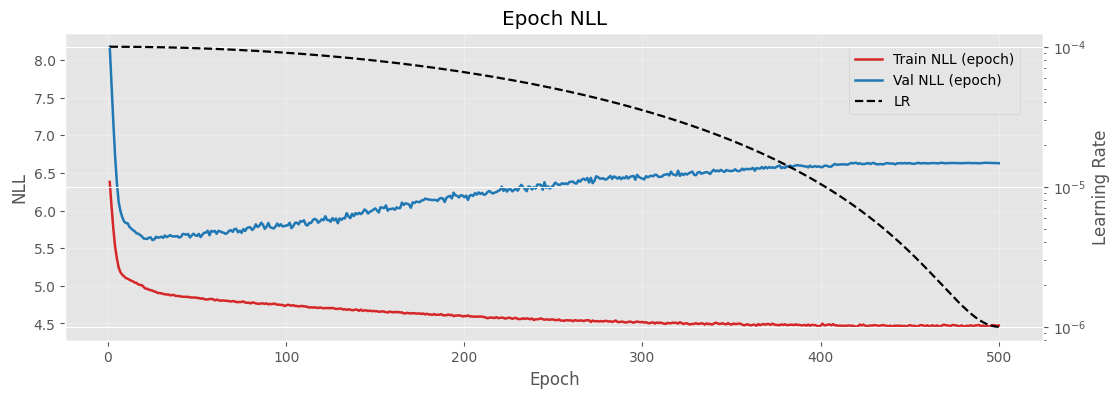

In [341]:
plot_loss(hist)

In [342]:
sigma_val_scaled_t, y_val_scale_t = predict_sigma(cov_model_t, vol_val_loader, device=device)
sigma_test_scaled_t, y_test_scaled_t = predict_sigma(cov_model_t, vol_test_loader, device=device)

sigma_val_real_t = scale_back(sigma_val_scaled_t, sigma=sigma, feature_cols=macro_tickers)
sigma_test_real_t = scale_back(sigma_test_scaled_t, sigma=sigma, feature_cols=macro_tickers)

In [343]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False)
sigma_train_scaled_t, y_train_scaled_t = predict_sigma(cov_model_t, vol_train_eval_loader, device=device)
sigma_train_real_t = scale_back(sigma_train_scaled_t, sigma=sigma, feature_cols=macro_tickers)

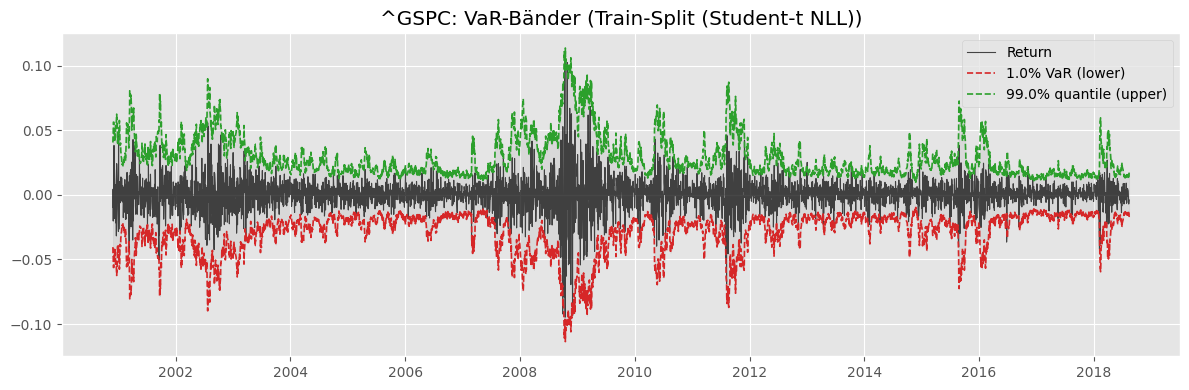

^GSPC: hit rate = 0.745% (target 1.000%)


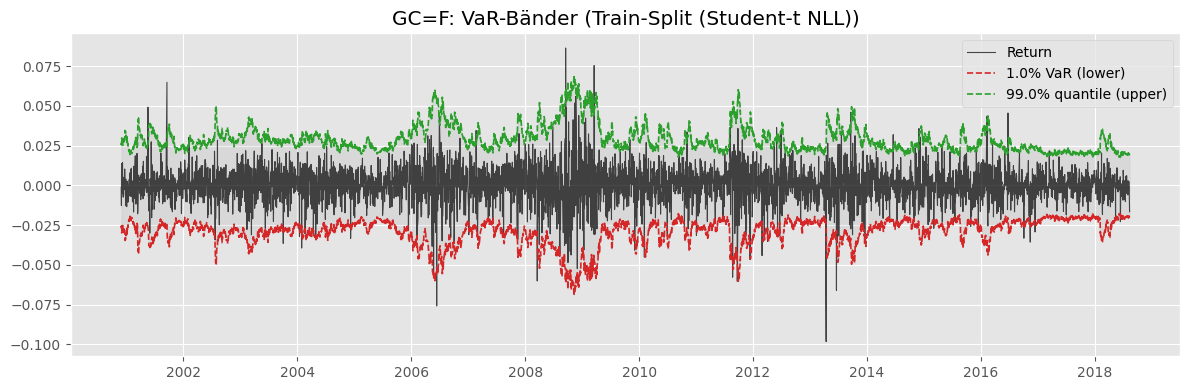

GC=F: hit rate = 1.106% (target 1.000%)


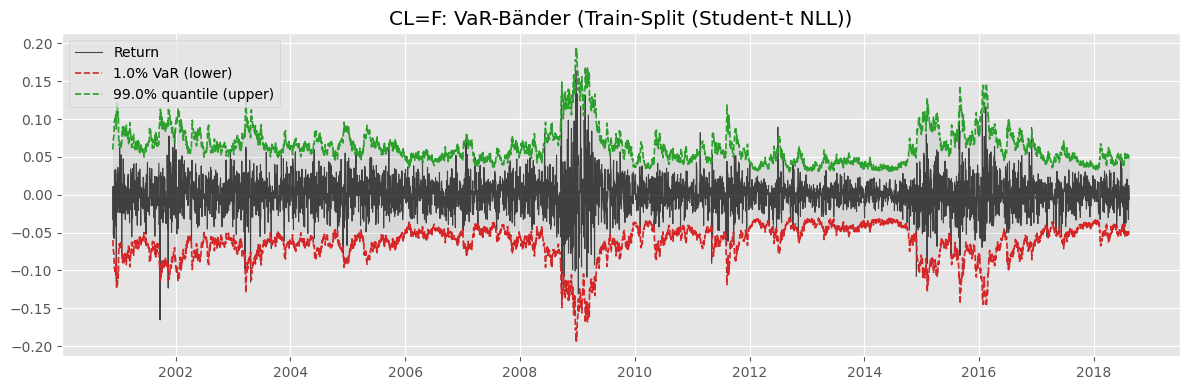

CL=F: hit rate = 0.655% (target 1.000%)


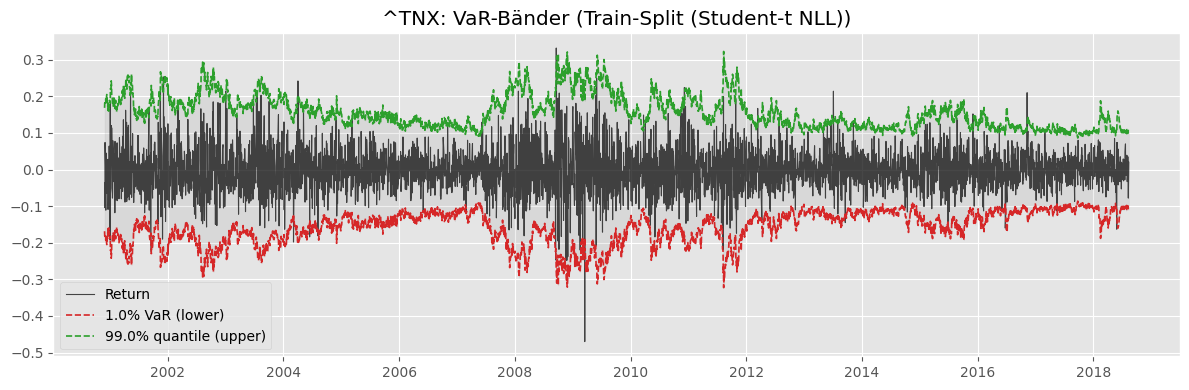

^TNX: hit rate = 0.339% (target 1.000%)


In [344]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Train-Split (Student-t NLL)", df=train_df, pred_vol=sigma_train_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

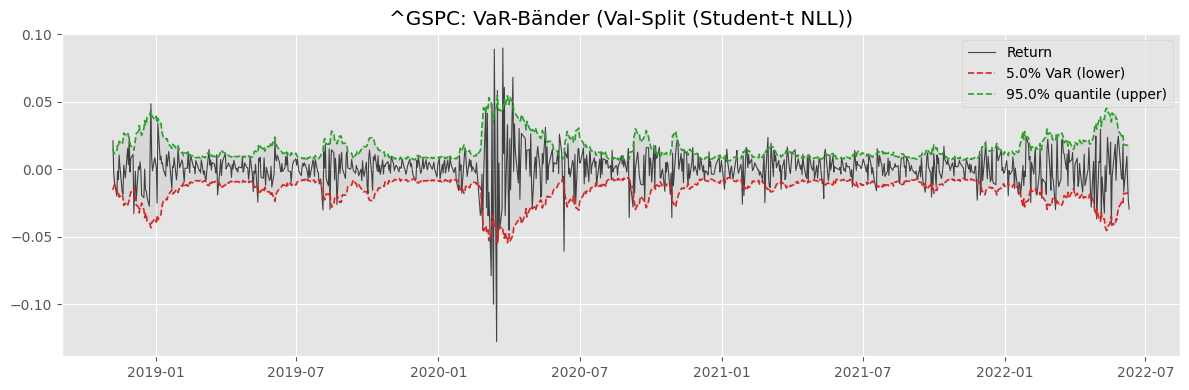

^GSPC: hit rate = 7.650% (target 5.000%)


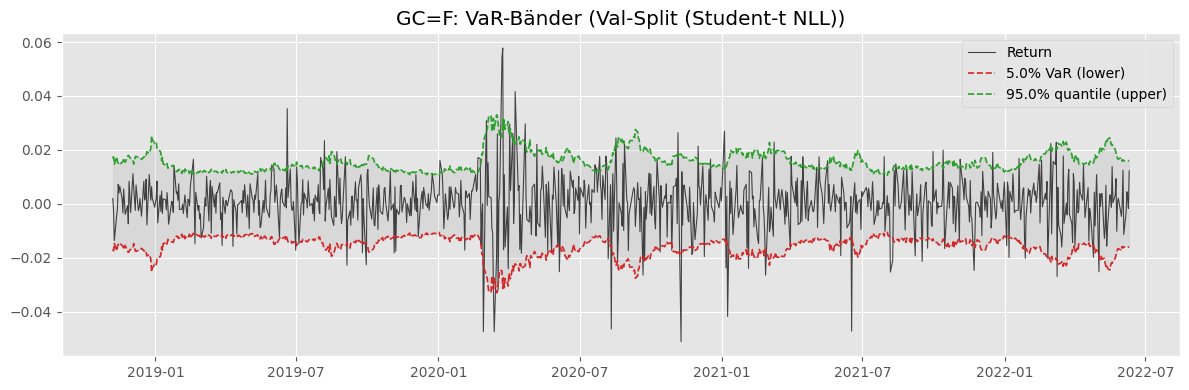

GC=F: hit rate = 5.432% (target 5.000%)


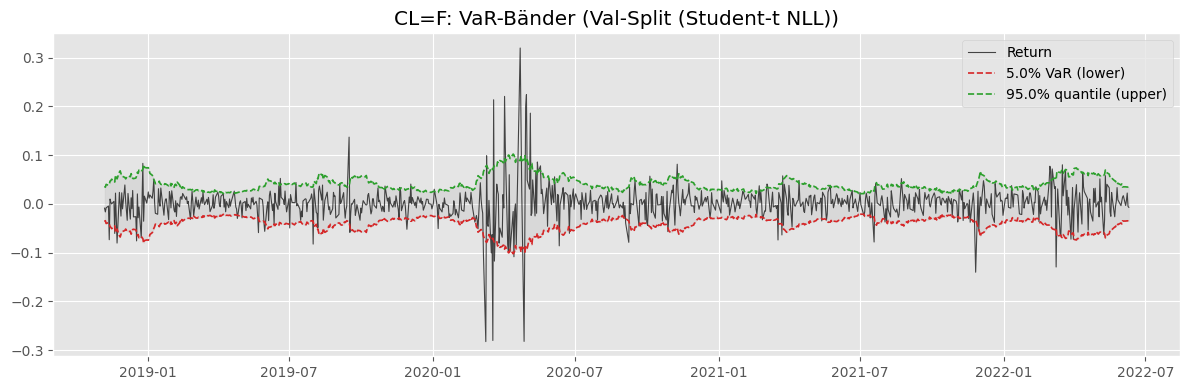

CL=F: hit rate = 6.098% (target 5.000%)


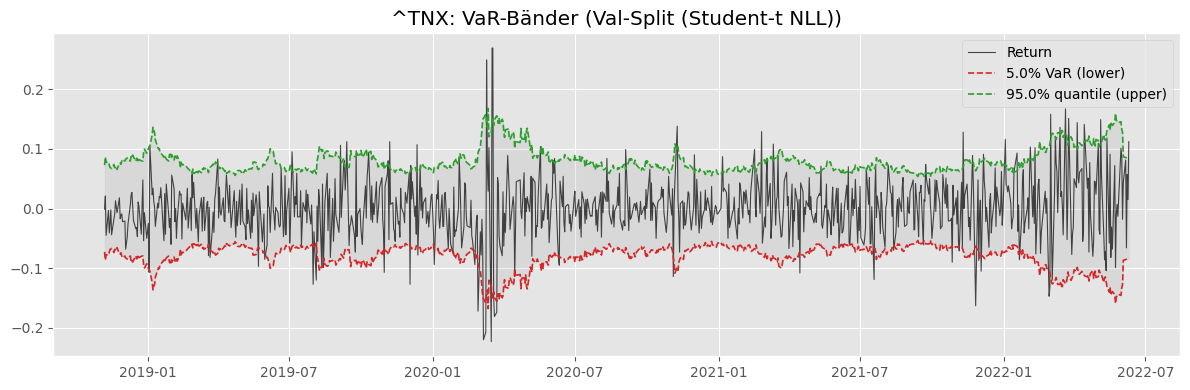

^TNX: hit rate = 4.324% (target 5.000%)


In [345]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Val-Split (Student-t NLL)", df=val_df, pred_vol=sigma_val_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

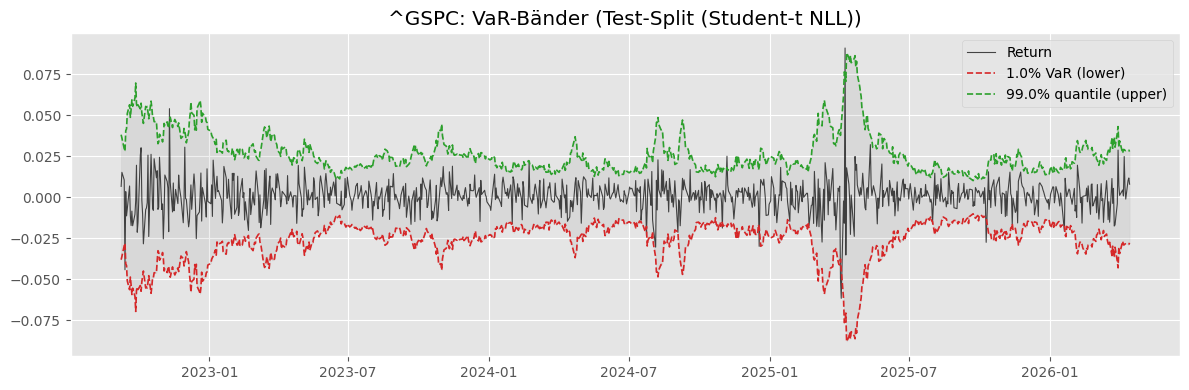

^GSPC: hit rate = 1.329% (target 1.000%)


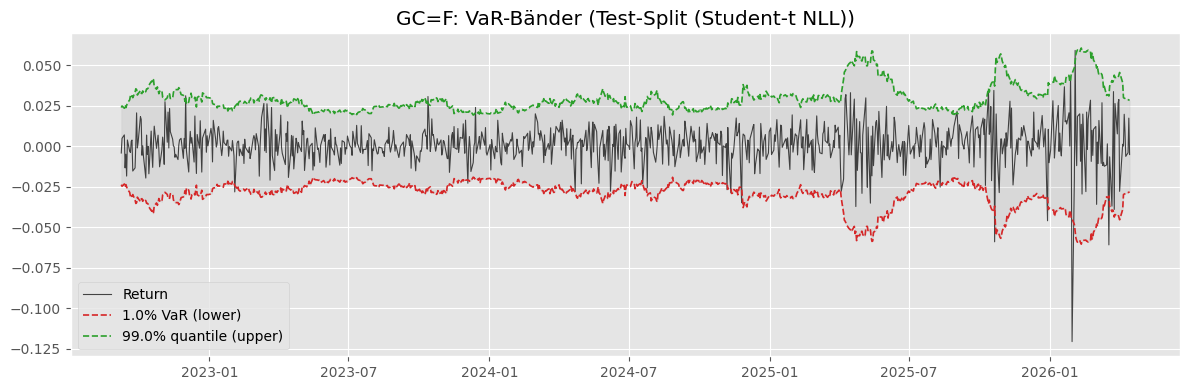

GC=F: hit rate = 1.107% (target 1.000%)


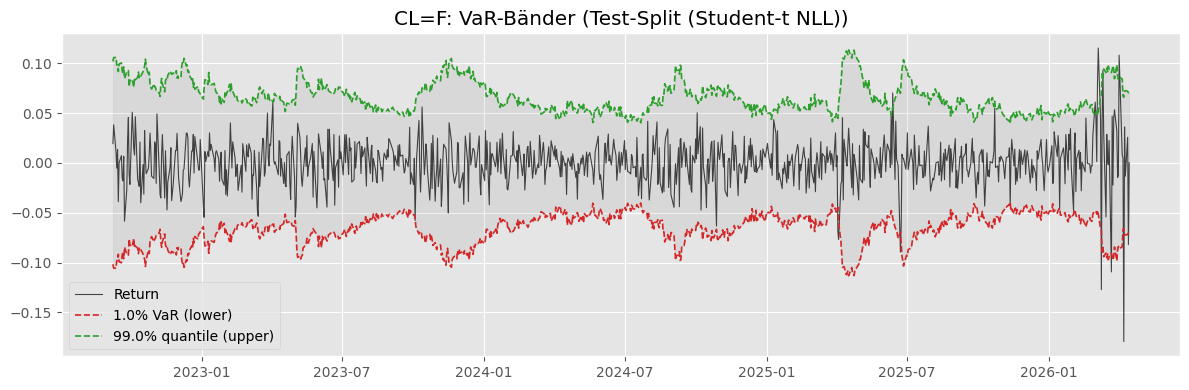

CL=F: hit rate = 1.107% (target 1.000%)


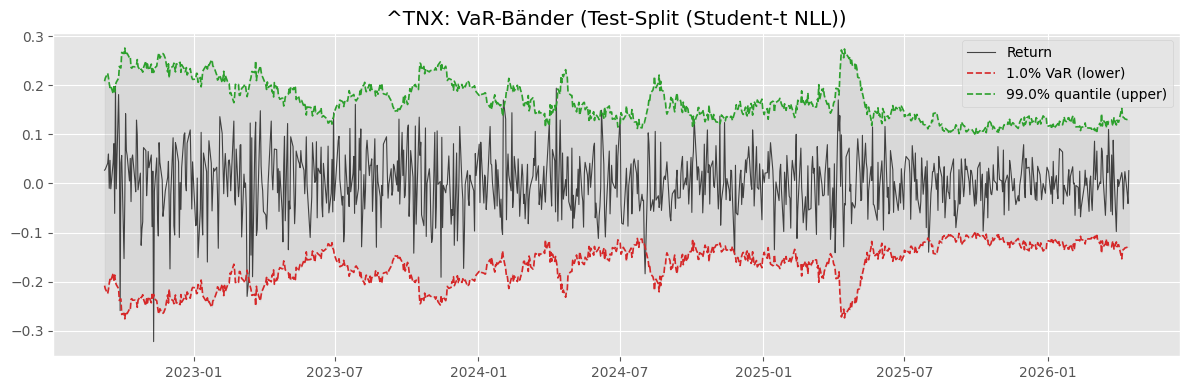

^TNX: hit rate = 0.775% (target 1.000%)


In [346]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split (Student-t NLL)", df=test_df, pred_vol=sigma_test_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

### Portfolio Returns

- Hier müssten jetzt noch mal die Portfolio Returns & Volas mit ```make_portfolio_df``` berechnet werden für Student-t Verteilung!

In [347]:
idx_test_t, rp_test_t, varp_test_t, volp_test_t = calc_portfolio_variance(
    test_df, sigma_test_real_t, macro_tickers, lookback, w_np
)

idx_val_t, rp_val_t, varp_val_t, volp_val_t = calc_portfolio_variance(
    val_df, sigma_val_real_t, macro_tickers, lookback, w_np
)

idx_train_t, rp_train_t, varp_train_t, volp_train_t = calc_portfolio_variance(
    train_df, sigma_train_real_t, macro_tickers, lookback, w_np
)

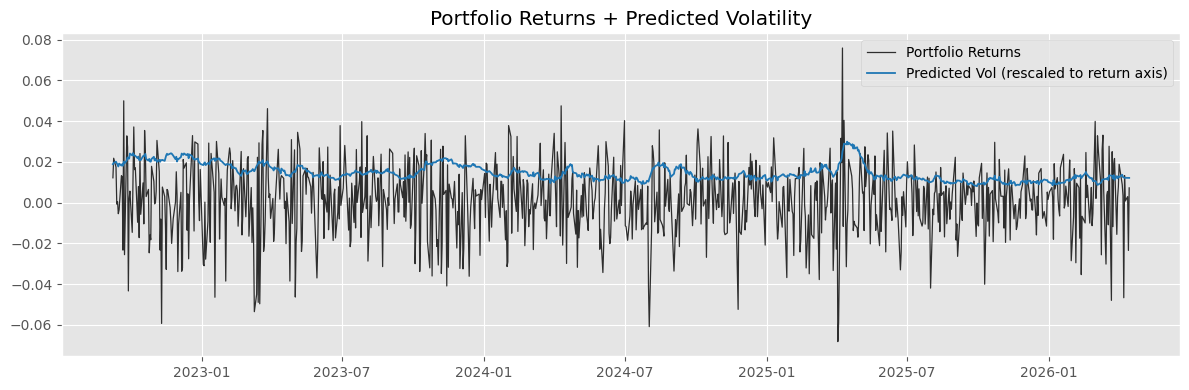

In [348]:
r = np.asarray(rp_test_t, dtype=float)
v = np.asarray(volp_test_t, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [349]:
portfolio_test_t = make_portfolio_df(idx_test_t, rp_test_t, varp_test_t, volp_test_t)
portfolio_val_t = make_portfolio_df(idx_val_t, rp_val_t, varp_val_t, volp_val_t)
portfolio_train_t = make_portfolio_df(idx_train_t, rp_train_t, varp_train_t, volp_train_t)

Modell mit skewed Studen-t-Verteilung

## Filtered Historical Simulation

- bisher FHS nur mit Normal Volas

In [350]:
from risk_metrics import fhs_var_es

In [351]:
alpha = 0.01
window = 1000  # z.B. 250/500/1000 testen

In [352]:
len(train_df), len(val_df), len(test_df)

(4490, 962, 963)

### Normal Loss (Portfolio)

In [353]:
z_train = portfolio_train["r_p"].values / np.clip(portfolio_train["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val = portfolio_val["r_p"].values / np.clip(portfolio_val["vol_p"].values, 1e-12, None)
z_test = portfolio_test["r_p"].values / np.clip(portfolio_test["vol_p"].values, 1e-12, None)
z_train_val =np.concatenate([z_train, z_val])


var_fhs_test, es_fhs_test, hits_test = fhs_var_es(
    z_hist_init=z_train_val, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test["r_p"].values,
    vol_oos=portfolio_test["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test = hits_test.mean()
print(f"FHS Test hit rate = {hit_rate_test:.3%} (target {alpha:.3%})")

FHS Test hit rate = 0.997% (target 1.000%)


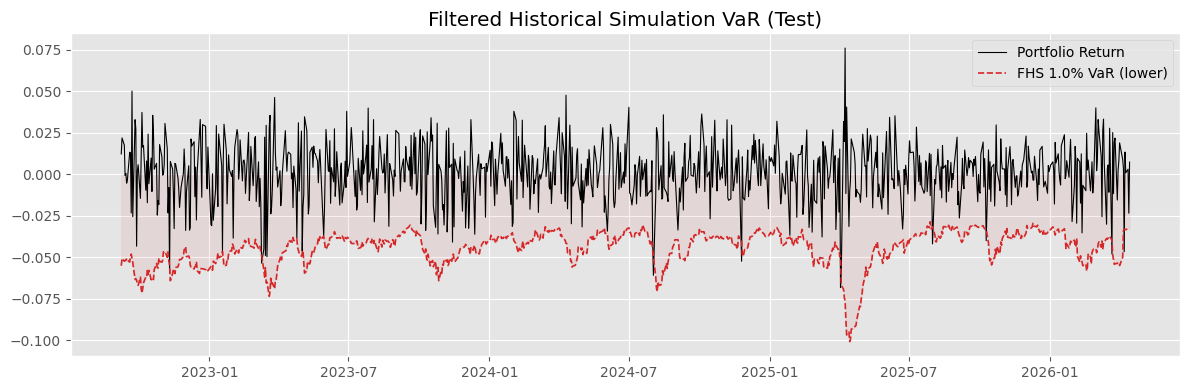

In [354]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_test.index, portfolio_test["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_test.index, var_fhs_test, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_test.index, var_fhs_test, np.zeros_like(var_fhs_test), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Test)")
plt.legend()
plt.tight_layout()
plt.show()

- Falls FHS auf train genutzt werden soll, muss zuvor ein z_train_burn_in genutzt werden wo zb die ersten 500 z_t aus train genutzt werden für die historie und von dort aus wird dann der VaR rollierend berechnet!

In [355]:
z_train_burn_in = z_train[:window]

In [356]:
var_fhs_train, es_fhs_train, hit_train = fhs_var_es(
    z_hist_init=z_train_burn_in, # custom burn-in für Historie nötig
    r_oos=portfolio_train["r_p"][window:].values,
    vol_oos=portfolio_train["vol_p"][window:].values,
    alpha=alpha,
    window=window
)

hit_rate_train = hit_train.mean()
print(f"FHS Train hit rate = {hit_rate_train:.3%} (target {alpha:.3%})")

FHS Train hit rate = 1.137% (target 1.000%)


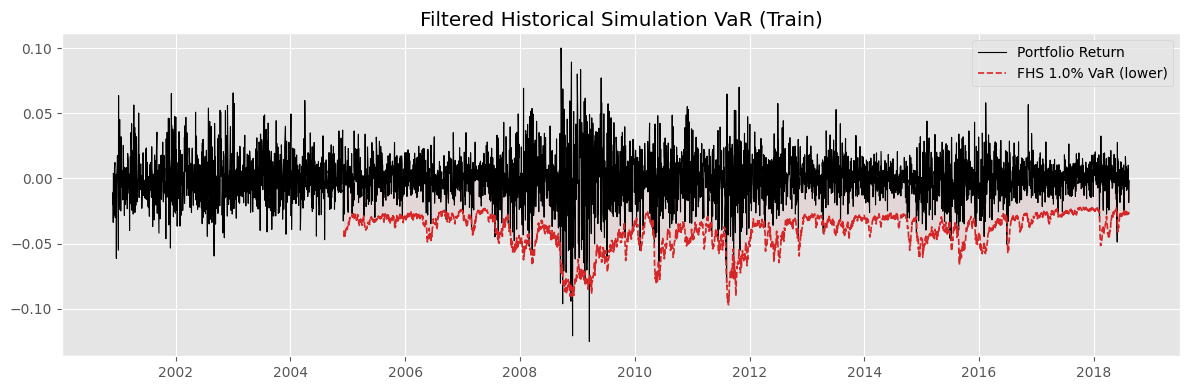

In [357]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_train.index, portfolio_train["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_train[window:].index, var_fhs_train, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_train[window:].index, var_fhs_train, np.zeros_like(var_fhs_train), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Train)")
plt.legend()
plt.tight_layout()
plt.show()

In [358]:
var_fhs_val, es_fhs_val, hit_val = fhs_var_es(
    z_hist_init=z_train,
    r_oos=portfolio_val["r_p"].values,
    vol_oos=portfolio_val["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_val = hit_val.mean()
print(f"FHS Val hit rate = {hit_rate_val:.3%} (target {alpha:.3%})")

FHS Val hit rate = 1.663% (target 1.000%)


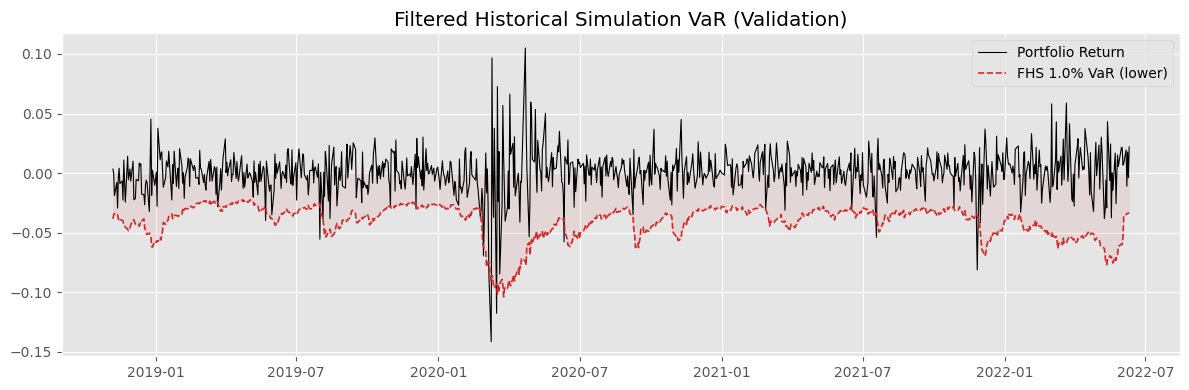

In [359]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_val.index, portfolio_val["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_val.index, var_fhs_val, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_val.index, var_fhs_val, np.zeros_like(var_fhs_val), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### Student-t Loss (Portfolio)

In [360]:
z_train_t = portfolio_train_t["r_p"].values / np.clip(portfolio_train_t["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_t = portfolio_val_t["r_p"].values / np.clip(portfolio_val_t["vol_p"].values, 1e-12, None)
z_test_t = portfolio_test_t["r_p"].values / np.clip(portfolio_test_t["vol_p"].values, 1e-12, None)
z_train_val_t =np.concatenate([z_train_t, z_val_t])


var_fhs_test_t, es_fhs_test_t, hits_test_t = fhs_var_es(
    z_hist_init=z_train_val_t, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_t["r_p"].values,
    vol_oos=portfolio_test_t["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_t = hits_test_t.mean()
print(f"FHS Test hit rate = {hit_rate_test_t:.3%} (target {alpha:.3%})")

FHS Test hit rate = 0.886% (target 1.000%)


# MGARCH-LSTM mit BEKK Kernel Function (Zhao et al. 2024)

$s_{t-1} := \operatorname{vech}(\Sigma_{t-1})$

$$
f_t = \sigma_g\!\left(W_f \varepsilon_{t-1} 
      + U_f s_{t-1} 
      + b_f\right), \\
i_t = \sigma_g\!\left(W_i \varepsilon_{t-1} 
      + U_i s_{t-1} 
      + b_i\right), \\
\tilde c_t = \sigma_c\!\left(W_c \varepsilon_{t-1} 
      + U_c s_{t-1} 
      + b_c\right), \\
c_t = f_t \odot c_{t-1} 
      + i_t \odot \tilde c_t.
$$

The output gate can then be reinterpreted as a BEKK kernel output
$$
o_t := \mathcal{K}_{\text{BEKK}}(\varepsilon_{t-1}, \Sigma_{t-1}; \Theta), \\
\mathcal{K}_{\text{BEKK}} = C C^\top 
      + A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A 
      + B^\top \Sigma_{t-1} B.
$$

$$m_t = 1 + \beta \tanh(w_o^\top \tanh(c_t) + b_o)$$

$$\Sigma_t
= o_t \times m_t = 
\underbrace{m_t}_{\text{LSTM}}
\times
\underbrace{
\left(
CC^\top
+
A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A
+
B^\top \Sigma_{t-1} B
\right)
}_{\text{BEKK(1,1)}}$$

In [361]:
from bekk_kernel import BEKKCell, BEKKLSTM

- Es müssen neue Dataset & Dataloader angelegt werden, da die MGARCH Kernel Function ein BEKK(1,1) ist. Daher ist der bisherige ```lookback=60``` nicht passend.

In [362]:
loss_kwargs = {"nu": 10.0}

```train_cov```ggf. zur Initialisierung nutzen. 

In [ ]:
train_cov = torch.cov(torch.tensor(train_norm[macro_tickers].values, dtype=torch.float32,).T)  # sample / long-term covariance from training data
train_cov

tensor([[ 1.0000, -0.0334,  0.2120,  0.3630],
        [-0.0334,  1.0000,  0.2228, -0.1268],
        [ 0.2120,  0.2228,  1.0000,  0.1833],
        [ 0.3630, -0.1268,  0.1833,  1.0000]])

In [410]:
bekk_kernel_lstm = BEKKLSTM(input_size=(len(macro_tickers)+k), n_assets=len(macro_tickers), hidden_size=64, asym=True, Sigma0=train_cov)
bekk_kernel_lstm, hist_bekk = train_covariance_model(
    bekk_kernel_lstm,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

/Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/training_functions.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nu = torch.tensor(nu, device=y.device, dtype=y.dtype)


Epoch 001 | train NLL 6.040034 | val NLL 5.990480 | lr 1.00e-04
Epoch 002 | train NLL 5.723763 | val NLL 5.753201 | lr 1.00e-04
Epoch 003 | train NLL 5.515025 | val NLL 5.598403 | lr 1.00e-04
Epoch 004 | train NLL 5.379736 | val NLL 5.499607 | lr 1.00e-04
Epoch 005 | train NLL 5.290794 | val NLL 5.443130 | lr 1.00e-04
Epoch 006 | train NLL 5.240295 | val NLL 5.415596 | lr 1.00e-04
Epoch 007 | train NLL 5.209645 | val NLL 5.403979 | lr 1.00e-04
Epoch 008 | train NLL 5.199804 | val NLL 5.396338 | lr 9.99e-05
Epoch 009 | train NLL 5.183511 | val NLL 5.392615 | lr 9.99e-05
Epoch 010 | train NLL 5.172900 | val NLL 5.387796 | lr 9.99e-05
Epoch 011 | train NLL 5.162218 | val NLL 5.383549 | lr 9.99e-05
Epoch 012 | train NLL 5.154509 | val NLL 5.378733 | lr 9.99e-05
Epoch 013 | train NLL 5.153001 | val NLL 5.373337 | lr 9.98e-05
Epoch 014 | train NLL 5.136685 | val NLL 5.366314 | lr 9.98e-05
Epoch 015 | train NLL 5.127960 | val NLL 5.357887 | lr 9.98e-05
Epoch 016 | train NLL 5.123452 | val NLL

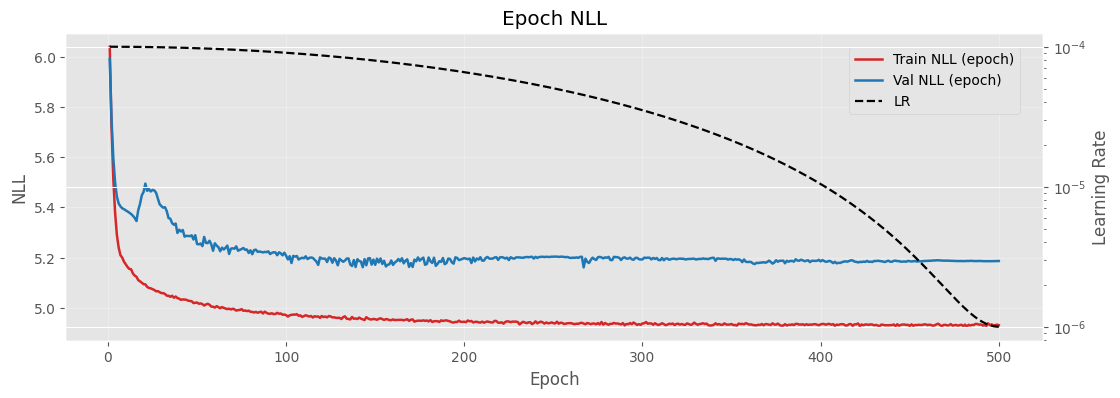

In [411]:
plot_loss(hist_bekk)

In [412]:
sigma_val_scaled_bekk, y_val_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_val_loader, device=device)
sigma_val_real_bekk = scale_back(sigma_val_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)

sigma_test_scaled_bekk, y_test_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_test_loader, device=device)
sigma_test_real_bekk = scale_back(sigma_test_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)


sigma_train_scaled_bekk, y_train_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_train_eval_loader, device=device)
sigma_train_real_bekk = scale_back(sigma_train_scaled_bekk, sigma=sigma, feature_cols=macro_tickers)

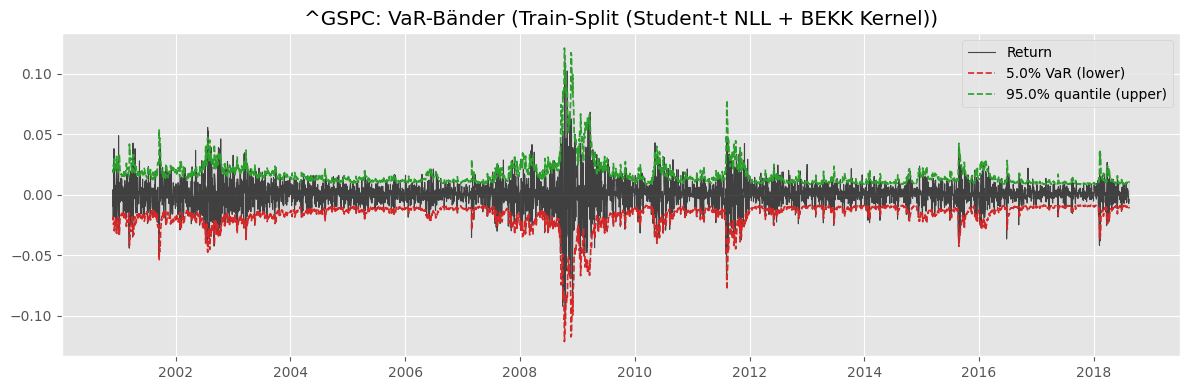

^GSPC: hit rate = 5.598% (target 5.000%)


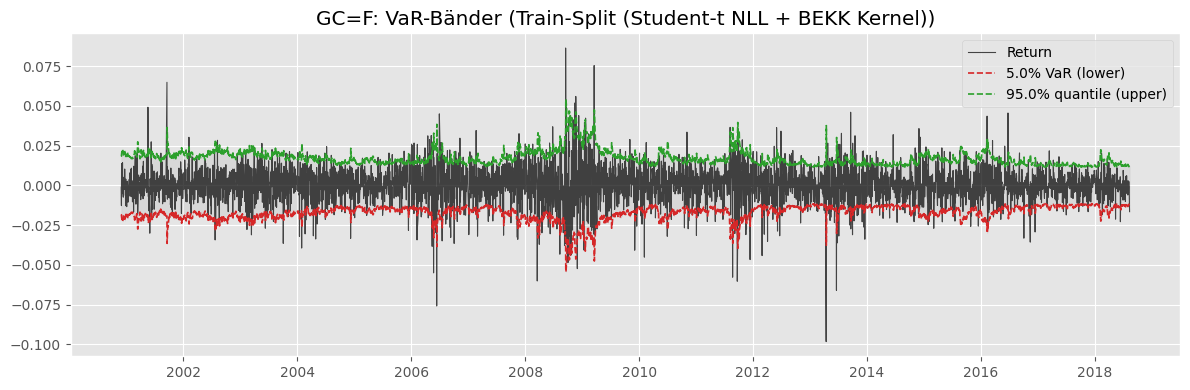

GC=F: hit rate = 5.418% (target 5.000%)


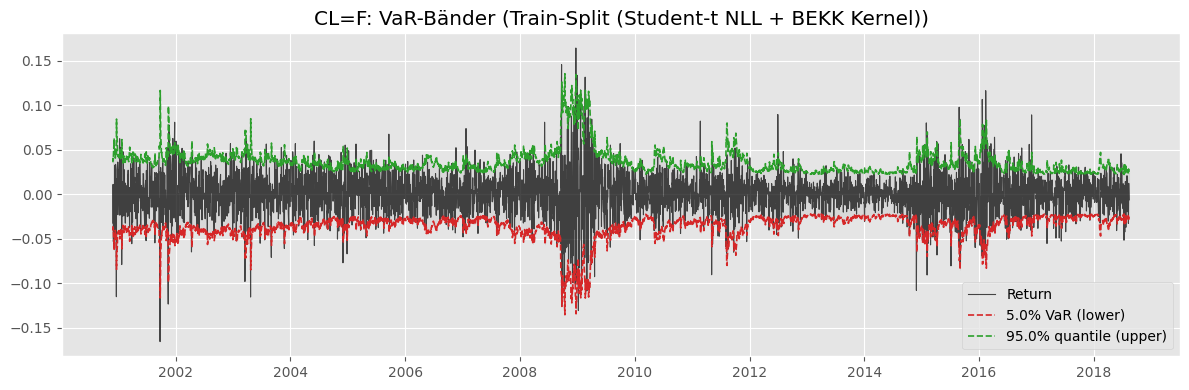

CL=F: hit rate = 5.305% (target 5.000%)


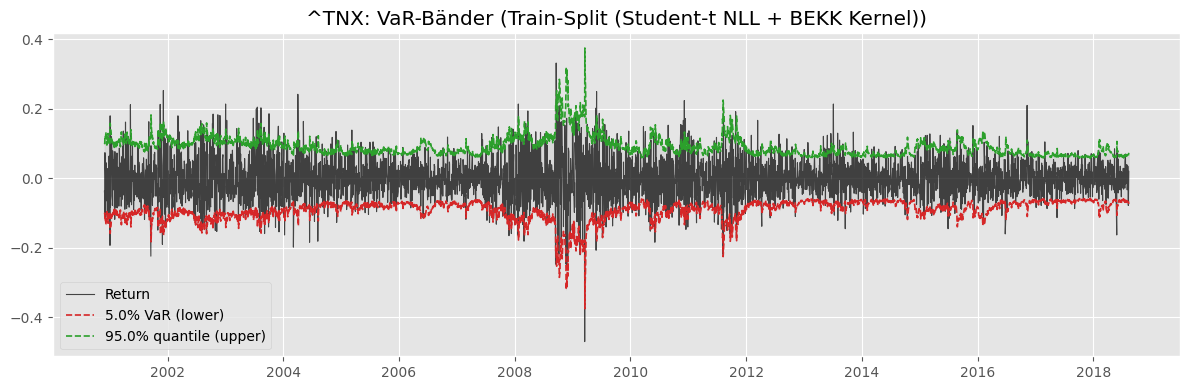

^TNX: hit rate = 4.808% (target 5.000%)


In [413]:
plot_var(alpha=0.05, lookback=lookback, cols=macro_tickers, view="Train-Split (Student-t NLL + BEKK Kernel)", df=train_df, pred_vol=sigma_train_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

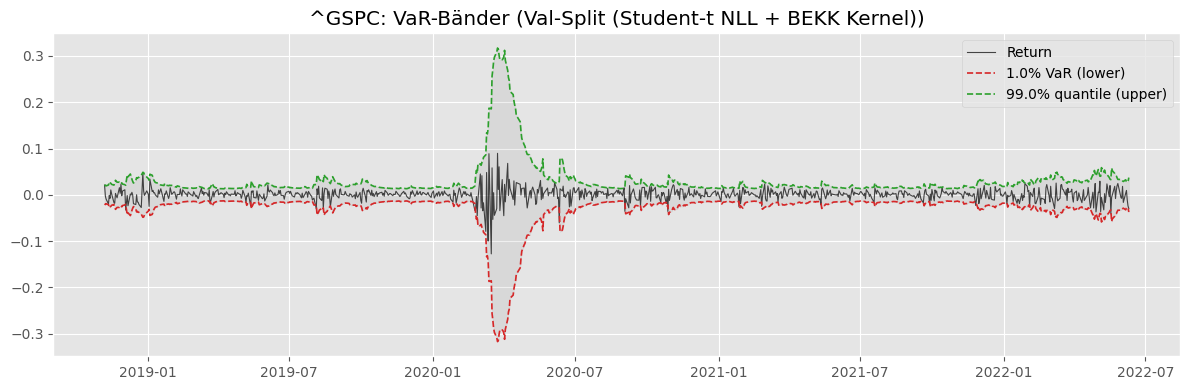

^GSPC: hit rate = 2.550% (target 1.000%)


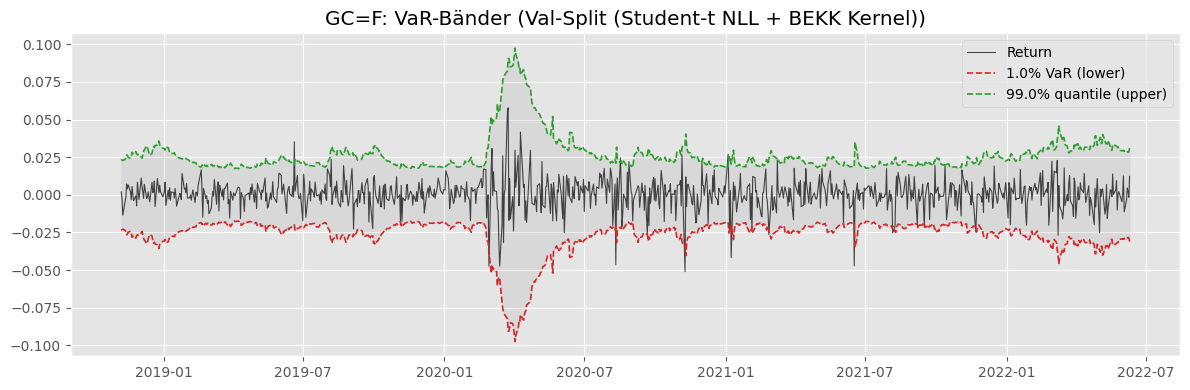

GC=F: hit rate = 1.441% (target 1.000%)


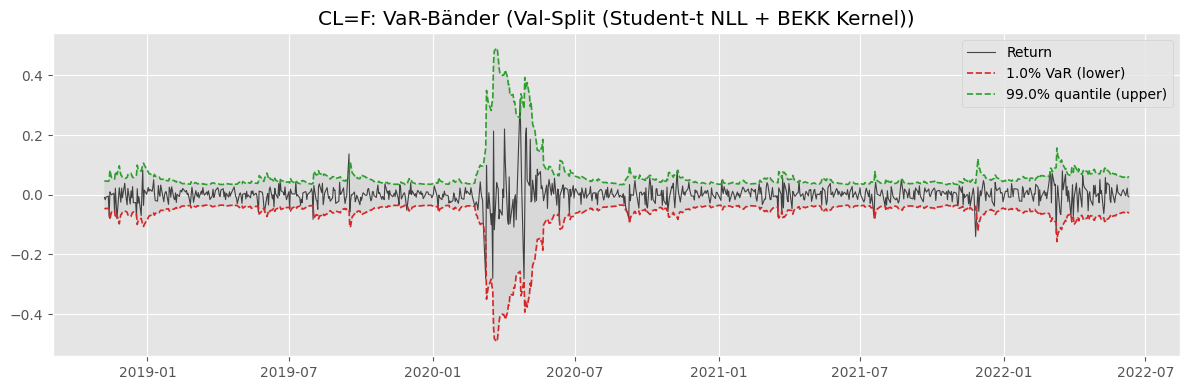

CL=F: hit rate = 2.439% (target 1.000%)


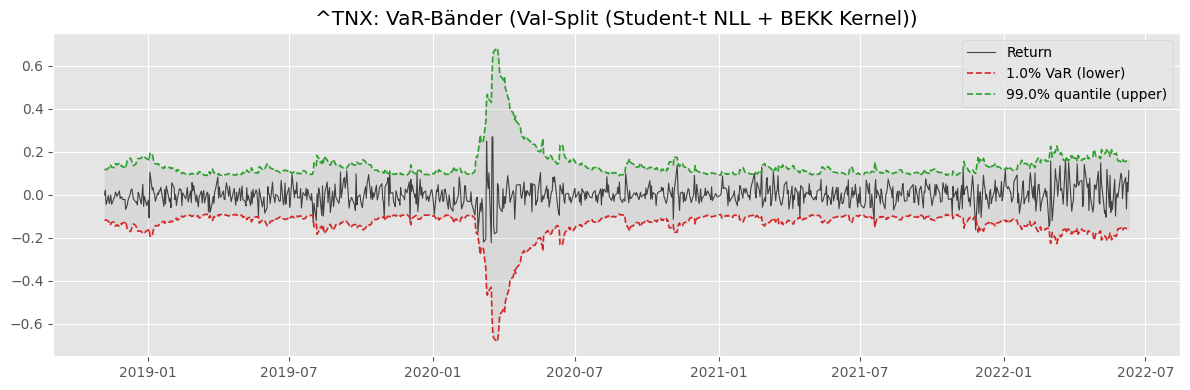

^TNX: hit rate = 0.665% (target 1.000%)


In [414]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Val-Split (Student-t NLL + BEKK Kernel)", df=val_df, pred_vol=sigma_val_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

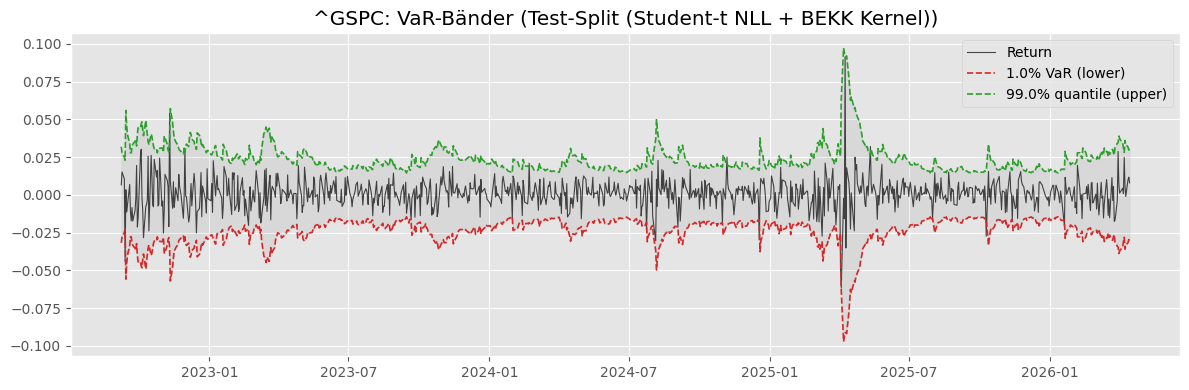

^GSPC: hit rate = 1.218% (target 1.000%)


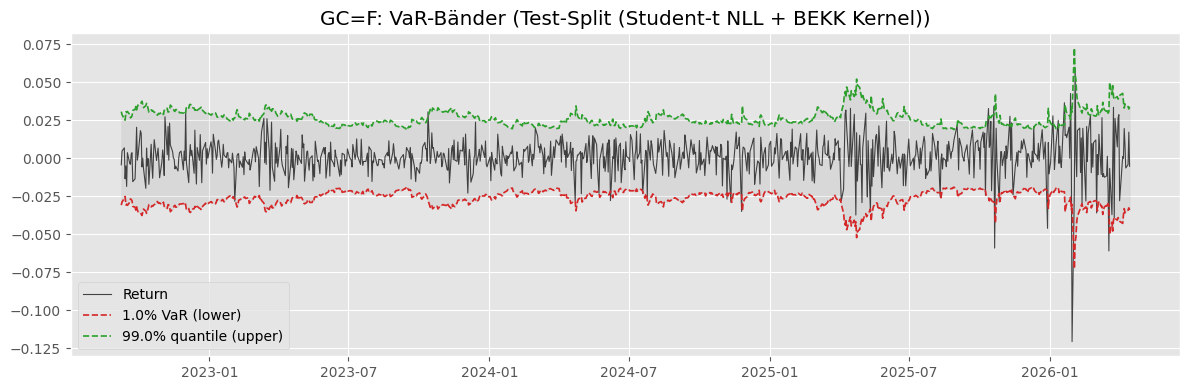

GC=F: hit rate = 1.883% (target 1.000%)


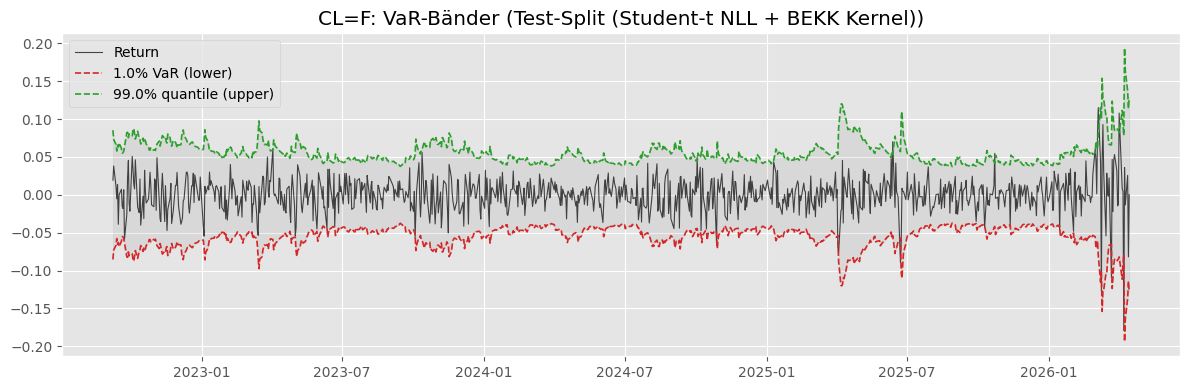

CL=F: hit rate = 1.218% (target 1.000%)


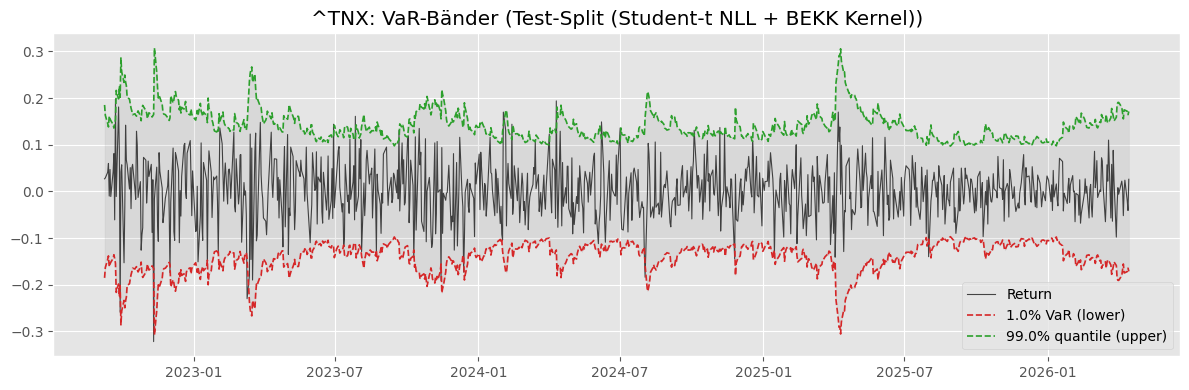

^TNX: hit rate = 1.772% (target 1.000%)


In [415]:
plot_var(alpha=0.01, lookback=lookback, cols=macro_tickers, view="Test-Split (Student-t NLL + BEKK Kernel)", df=test_df, pred_vol=sigma_test_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

## Portfolio

In [416]:
idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk = calc_portfolio_variance(
    test_df, sigma_test_real_bekk, macro_tickers, lookback, w_np
)

idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk = calc_portfolio_variance(
    val_df, sigma_val_real_bekk, macro_tickers, lookback, w_np
)

idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk = calc_portfolio_variance(
    train_df, sigma_train_real_bekk, macro_tickers, lookback, w_np
)

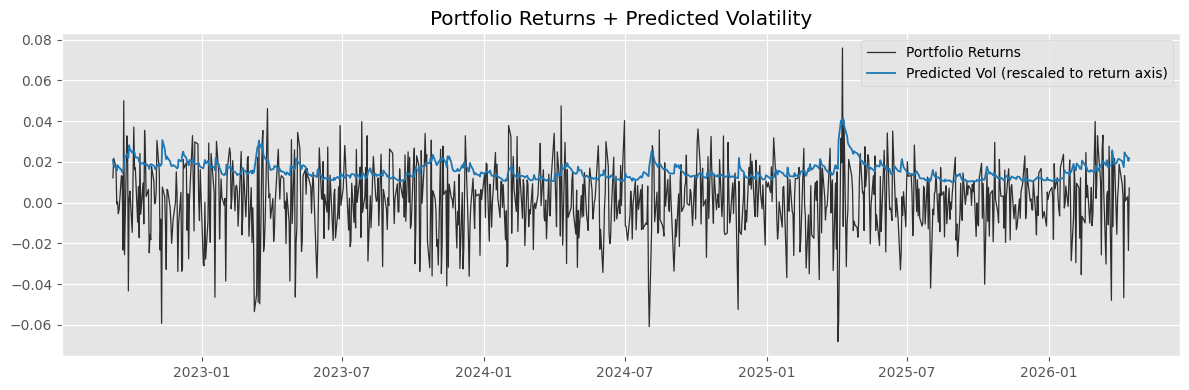

In [417]:
r = np.asarray(rp_test_bekk, dtype=float)
v = np.asarray(volp_test_bekk, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test_bekk, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test_bekk, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [418]:
portfolio_test_bekk = make_portfolio_df(idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk)
portfolio_val_bekk = make_portfolio_df(idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk)
portfolio_train_bekk = make_portfolio_df(idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk)

## FHS

In [372]:
z_train_bekk = portfolio_train_bekk["r_p"].values / np.clip(portfolio_train_bekk["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_bekk = portfolio_val_bekk["r_p"].values / np.clip(portfolio_val_bekk["vol_p"].values, 1e-12, None)
z_test_bekk = portfolio_test_bekk["r_p"].values / np.clip(portfolio_test_bekk["vol_p"].values, 1e-12, None)
z_train_val_bekk =np.concatenate([z_train_bekk, z_val_bekk])


var_fhs_test_bekk, es_fhs_test_bekk, hits_test_bekk = fhs_var_es(
    z_hist_init=z_train_val_bekk, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_bekk["r_p"].values,
    vol_oos=portfolio_test_bekk["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_bekk = hits_test_bekk.mean()
print(f"FHS Test hit rate = {hit_rate_test_bekk:.3%} (target {alpha:.3%})")

FHS Test hit rate = 1.440% (target 1.000%)


In [373]:
len(close)

6418

# Backtesting

!!! Backtestings müssen mit dem selben $\alpha$ vorgenommen werden wie mit FHS !!!

Backtests sind für univariate Zeitreihen definiert, d.h. wir testen alle Modelle im Kontext eines vordefinierten Portfolios.

In [374]:
#importlib.reload(backtesting)

In [375]:
from backtesting import run_backtest_suite

In [376]:
results = run_backtest_suite(
    returns=portfolio_test["r_p"].values,
    var=var_fhs_test,
    es=es_fhs_test,
    alpha=alpha,
    volatility=portfolio_test["vol_p"].values,  # optional, aber für CC/ER sinnvoll
)

results

{'meta': {'alpha': 0.01, 'n_obs': 903},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 9,
   'expected_exceptions': 9.03,
   'hit_rate': 0.009966777408637873,
   'lr_uc': 0.00010078506586808089,
   'p_value': 0.991990030572733},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 9,
   'hit_rate': 0.009966777408637873,
   'transition_counts': {'n00': 884, 'n01': 9, 'n10': 9, 'n11': 0},
   'transition_probs': {'pi_01': 0.010078387458006719,
    'pi_11': 0.0,
    'pi_pooled': 0.009977827050997782},
   'lr_ind': 0.18141404547213824,
   'p_value_ind': 0.6701608380086652,
   'lr_uc': 0.00010078506586808089,
   'lr_cc': 0.18151483053800632,
   'p_value_cc': 0.9132392219215693}},
 'cc': {'pvalue_twosided_simple': 0.009981952944308037,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.5562477382622295,
  'pvalue_onesided_general': 1.0,
  'n_obs': 903},
 'er': {'pvalue_twosided_simp

In [377]:
results_student = run_backtest_suite(
    returns=portfolio_test_t["r_p"].values,
    var=var_fhs_test_t,
    es=es_fhs_test_t,
    alpha=alpha,
    volatility=portfolio_test_t["vol_p"].values,
)

results_student

{'meta': {'alpha': 0.01, 'n_obs': 903},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 8,
   'expected_exceptions': 9.03,
   'hit_rate': 0.008859357696566999,
   'lr_uc': 0.12341306136990227,
   'p_value': 0.7253618307888009},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 8,
   'hit_rate': 0.008859357696566999,
   'transition_counts': {'n00': 887, 'n01': 7, 'n10': 7, 'n11': 1},
   'transition_probs': {'pi_01': 0.007829977628635347,
    'pi_11': 0.125,
    'pi_pooled': 0.008869179600886918},
   'lr_ind': 3.6610956294745876,
   'p_value_ind': 0.05569699579120193,
   'lr_uc': 0.12341306136990227,
   'lr_cc': 3.78450869084449,
   'p_value_cc': 0.15073162438638923}},
 'cc': {'pvalue_twosided_simple': 0.0005893939524094227,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.4668569093867886,
  'pvalue_onesided_general': 0.7353562071101196,
  'n_obs': 903},
 'er': {'pvalue_tw

In [419]:
results_bekk = run_backtest_suite(
    returns=portfolio_test_bekk["r_p"].values,
    var=var_fhs_test_bekk,
    es=es_fhs_test_bekk,
    alpha=alpha,
    volatility=portfolio_test_bekk["vol_p"].values,
)

results_bekk

{'meta': {'alpha': 0.01, 'n_obs': 903},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 13,
   'expected_exceptions': 9.03,
   'hit_rate': 0.014396456256921373,
   'lr_uc': 1.5519781304575417,
   'p_value': 0.212843652694687},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 13,
   'hit_rate': 0.014396456256921373,
   'transition_counts': {'n00': 877, 'n01': 12, 'n10': 12, 'n11': 1},
   'transition_probs': {'pi_01': 0.013498312710911136,
    'pi_11': 0.07692307692307693,
    'pi_pooled': 0.014412416851441241},
   'lr_ind': 1.8302419281614846,
   'p_value_ind': 0.17609897281066614,
   'lr_uc': 1.5519781304575417,
   'lr_cc': 3.3822200586190263,
   'p_value_cc': 0.18431481555038484}},
 'cc': {'pvalue_twosided_simple': 7.006322874980597e-05,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.008885282347763757,
  'pvalue_onesided_general': 1.0,
  'n_obs': 903},
 'er': {'pvalu

# BEKK(1, 1) symmetrisch & asymmetrisch

importiert aus R bzw BEKKs Library.

## Daten import

In [379]:
import shutil
import subprocess

In [380]:
rscript = shutil.which("Rscript")
if rscript is None:
    raise RuntimeError("Rscript wurde nicht gefunden. Prüfe, ob R im PATH liegt.")

In [381]:
cmd = [
    rscript,
    str(project_dir / "r" / "bekks.R"),
    "--run-id", run_id,
    "--project-dir", str(project_dir)
]

result = subprocess.run(
    cmd,
    cwd=project_dir,
    capture_output=True,
    text=True,
    check=False,
)

print("R stdout:")
print(result.stdout)

if result.stderr:
    print("R stderr:")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"bekks.R failed with return code {result.returncode}")

print(f"BEKK run finished: {run_id}")


R stdout:
BEKK(1,1) forecasts finished
run_id: 2026-04-16
project_dir: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk
output_dir: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/r/output
assets: ^GSPC, GC=F, CL=F, ^TNX
train / val / test rows: 4490 / 962 / 963
symmetric train+val CSV: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/r/output/bekk_forecasts_fitted_train_val_symmetric_2026-04-16.csv
symmetric forecast CSV: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/r/output/bekk_forecasts_symmetric_2026-04-16.csv
asymmetric train+val CSV: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/r/output/bekk_forecasts_fitted_train_val_asymmetric_2026-04-16.csv
asymmetric forecast CSV: /Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk/r/output/bekk_forecasts_asymmetric_2026-04-16.csv

BEKK run finished: 2026-04-16


In [382]:
def load_bekk_covariances(path, d):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"BEKK forecast file not found: {path}")

    df = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")

    expected_cols = [
        f"h_{i}{j}"
        for i in range(1, d + 1)
        for j in range(1, d + 1)
    ]

    missing_cols = [col for col in expected_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing covariance columns in {path}: {missing_cols}")

    H = df[expected_cols].to_numpy(dtype=float).reshape(len(df), d, d)

    return df, H

sym_path = output_dir / f"bekk_forecasts_symmetric_{run_id}.csv"
asym_path = output_dir / f"bekk_forecasts_asymmetric_{run_id}.csv"

bekk_sym_df, H_bekk_sym = load_bekk_covariances(sym_path, d=len(macro_tickers))
bekk_asym_df, H_bekk_asym = load_bekk_covariances(asym_path, d=len(macro_tickers))

if len(H_bekk_sym) != len(test_df):
    raise ValueError(f"Symmetric BEKK length mismatch: {len(H_bekk_sym)} vs test_df {len(test_df)}")

if len(H_bekk_asym) != len(test_df):
    raise ValueError(f"Asymmetric BEKK length mismatch: {len(H_bekk_asym)} vs test_df {len(test_df)}")

print("Symmetric BEKK:", H_bekk_sym.shape)
print("Asymmetric BEKK:", H_bekk_asym.shape)


Symmetric BEKK: (963, 4, 4)
Asymmetric BEKK: (963, 4, 4)


In [383]:
sigma_test_real.shape

(903, 4, 4)

BEKK(1, 1) hat ```lookback``` mehr OOS predictions als die LSTM Modelle

In [384]:
H_bekk_sym_aligned = H_bekk_sym[lookback:]
H_bekk_asym_aligned = H_bekk_asym[lookback:]

idx_bekk_sym, rp_bekk_sym, varp_bekk_sym, volp_bekk_sym = calc_portfolio_variance(
    test_df,
    H_bekk_sym_aligned,
    macro_tickers,
    lookback,
    w_np,
)

idx_bekk_asym, rp_bekk_asym, varp_bekk_asym, volp_bekk_asym = calc_portfolio_variance(
    test_df,
    H_bekk_asym_aligned,
    macro_tickers,
    lookback,
    w_np,
)


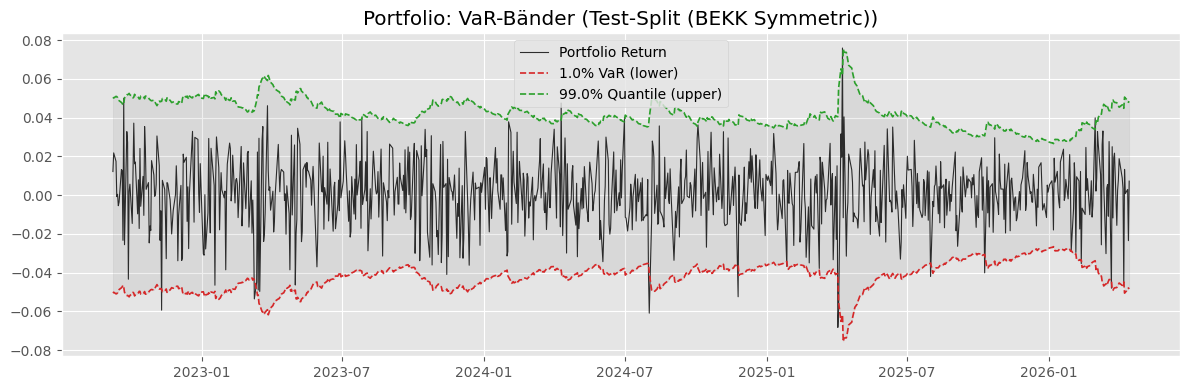

Portfolio hit rate = 1.440% (target 1.000%)


In [385]:
portfolio_test_bekk_sym = make_portfolio_df(idx_bekk_sym, rp_bekk_sym, varp_bekk_sym, volp_bekk_sym)

plot_var(alpha=0.01, lookback=lookback, view="Test-Split (BEKK Symmetric)", portfolio=True, portfolio_df=portfolio_test_bekk_sym)

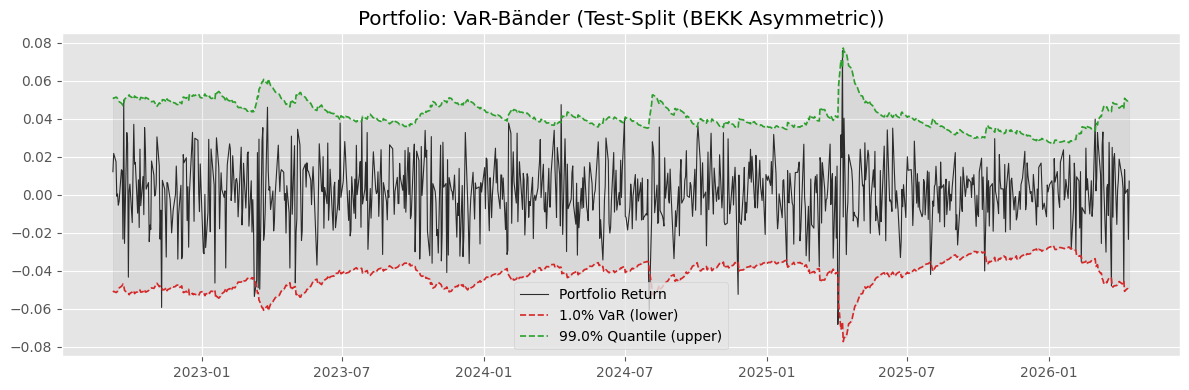

Portfolio hit rate = 1.661% (target 1.000%)


In [386]:
portfolio_test_bekk_asym = make_portfolio_df(idx_bekk_asym, rp_bekk_asym, varp_bekk_asym, volp_bekk_asym)

plot_var(alpha=0.01, lookback=lookback, view="Test-Split (BEKK Asymmetric)", portfolio=True, portfolio_df=portfolio_test_bekk_asym)

## FHS

In [387]:
trainval_sym_path = output_dir / f"bekk_forecasts_fitted_train_val_symmetric_{run_id}.csv"
trainval_asym_path = output_dir / f"bekk_forecasts_fitted_train_val_asymmetric_{run_id}.csv"

_, H_bekk_sym_trainval = load_bekk_covariances(trainval_sym_path, d=len(macro_tickers))
_, H_bekk_asym_trainval = load_bekk_covariances(trainval_asym_path, d=len(macro_tickers))

In [388]:
train_val_returns_df = pd.concat(
    [train_df[macro_tickers], val_df[macro_tickers]],
    axis=0,
)

idx_sym_hist, rp_sym_hist, varp_sym_hist, volp_sym_hist = calc_portfolio_variance(
    train_val_returns_df,
    H_bekk_sym_trainval,
    macro_tickers,
    0,
    w_np,
)

idx_asym_hist, rp_asym_hist, varp_asym_hist, volp_asym_hist = calc_portfolio_variance(
    train_val_returns_df,
    H_bekk_asym_trainval,
    macro_tickers,
    0,
    w_np,
)

portfolio_hist_bekk_sym = make_portfolio_df(idx_sym_hist, rp_sym_hist, varp_sym_hist, volp_sym_hist)
portfolio_hist_bekk_asym = make_portfolio_df(idx_asym_hist, rp_asym_hist, varp_asym_hist, volp_asym_hist)

In [389]:
z_hist_sym = portfolio_hist_bekk_sym["r_p"].values / np.clip(
    portfolio_hist_bekk_sym["vol_p"].values,
    1e-12,
    None,
)

z_hist_asym = portfolio_hist_bekk_asym["r_p"].values / np.clip(
    portfolio_hist_bekk_asym["vol_p"].values,
    1e-12,
    None,
)

var_fhs_test_bekk_sym, es_fhs_test_bekk_sym, hits_test_bekk_sym = fhs_var_es(
    z_hist_init=z_hist_sym,
    r_oos=portfolio_test_bekk_sym["r_p"].values,
    vol_oos=portfolio_test_bekk_sym["vol_p"].values,
    alpha=alpha,
    window=window,
)

var_fhs_test_bekk_asym, es_fhs_test_bekk_asym, hits_test_bekk_asym = fhs_var_es(
    z_hist_init=z_hist_asym,
    r_oos=portfolio_test_bekk_asym["r_p"].values,
    vol_oos=portfolio_test_bekk_asym["vol_p"].values,
    alpha=alpha,
    window=window,
)

print("Sym BEKK hit rate:", hits_test_bekk_sym.mean())
print("Asym BEKK hit rate:", hits_test_bekk_asym.mean())


Sym BEKK hit rate: 0.01107419712070875
Asym BEKK hit rate: 0.012181616832779624


## Backtest

In [390]:
results_bekk_sym = run_backtest_suite(
    returns=portfolio_test_bekk_sym["r_p"].values,
    var=var_fhs_test_bekk_sym,
    es=es_fhs_test_bekk_sym,
    alpha=alpha,
    volatility=portfolio_test_bekk_sym["vol_p"].values,
)

results_bekk_sym

{'meta': {'alpha': 0.01, 'n_obs': 903},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 10,
   'expected_exceptions': 9.03,
   'hit_rate': 0.01107419712070875,
   'lr_uc': 0.10170738834787585,
   'p_value': 0.7497902428653431},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 10,
   'hit_rate': 0.01107419712070875,
   'transition_counts': {'n00': 883, 'n01': 9, 'n10': 9, 'n11': 1},
   'transition_probs': {'pi_01': 0.010089686098654708,
    'pi_11': 0.1,
    'pi_pooled': 0.011086474501108648},
   'lr_ind': 2.7864184784351664,
   'p_value_ind': 0.0950664849971245,
   'lr_uc': 0.10170738834787585,
   'lr_cc': 2.8881258667830423,
   'p_value_cc': 0.23596708986820888}},
 'cc': {'pvalue_twosided_simple': 0.005421659352952135,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.0840020809291333,
  'pvalue_onesided_general': 1.0,
  'n_obs': 903},
 'er': {'pvalue_twosided_simple': 0

In [391]:
results_bekk_asym = run_backtest_suite(
    returns=portfolio_test_bekk_asym["r_p"].values,
    var=var_fhs_test_bekk_asym,
    es=es_fhs_test_bekk_asym,
    alpha=alpha,
    volatility=portfolio_test_bekk_asym["vol_p"].values,
)

results_bekk_asym

{'meta': {'alpha': 0.01, 'n_obs': 903},
 'var': {'kupiec': {'test': 'kupiec_uc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 11,
   'expected_exceptions': 9.03,
   'hit_rate': 0.012181616832779624,
   'lr_uc': 0.4058883076097999,
   'p_value': 0.5240638502761901},
  'christoffersen': {'test': 'christoffersen_cc',
   'alpha': 0.01,
   'n_obs': 903,
   'n_exceptions': 11,
   'hit_rate': 0.012181616832779624,
   'transition_counts': {'n00': 881, 'n01': 10, 'n10': 10, 'n11': 1},
   'transition_probs': {'pi_01': 0.01122334455667789,
    'pi_11': 0.09090909090909091,
    'pi_pooled': 0.012195121951219513},
   'lr_ind': 2.428603303190613,
   'p_value_ind': 0.1191390082222364,
   'lr_uc': 0.4058883076097999,
   'lr_cc': 2.834491610800413,
   'p_value_cc': 0.24238066195076435}},
 'cc': {'pvalue_twosided_simple': 0.013997445384738127,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.05890026296964257,
  'pvalue_onesided_general': 1.0,
  'n_obs': 903},
 'er': {'pvalue_two

In [394]:
all_backtest_results = {
    "lstm_normal": results,
    "lstm_student": results_student,
    "neural_bekk": results_bekk,
    "bekk_symmetric": results_bekk_sym,
    "bekk_asymmetric": results_bekk_asym,
}

In [399]:
import json

In [402]:
result_save = "results/all_backtest_results.json"

with open(project_dir / result_save, "w", encoding="utf-8") as f:
    json.dump(all_backtest_results, f, indent=2)

# Rolling Block Re-Estimation

In [392]:
#from rolling_forecast import run_block_reestimation

In [393]:
result = run_block_reestimation(
    data=input_df,
    target_cols=macro_tickers,
    model_factory=lambda: LSTMCovariance(
        input_size=len(input_df.columns),
        n_assets=len(macro_tickers),
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
    ),
    lookback=60,
    train_window=1000,
    refit_every=100,
    val_size=100,
    batch_size=64,
    device=device,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    train_kwargs={"epochs": 200, "lr": 1e-4, "scheduler_type": "cosine"},
    verbose=False,
)

NameError: name 'run_block_reestimation' is not defined